# 🎯 Refined Hypothesis Framework + Complete Analysis Notebook

## Part 1: Hypothesis Refinement (Post-Validation Adjustments)

### Key Changes from Validation Results

1. **Composite splits create new testable dimensions**
2. **Temporal instability → use END variants**
3. **Negative α → document, test interactions**
4. **Low PC1 → treat as moderators, not main effects**

---

### H1: Love-Over-Sex Balance (REVISED)

**Original Hypothesis:**

> Books with higher (love + intimacy) / explicit-sex ratios receive higher ratings

**Post-Split Refinements:**

| Test | Formula | Rationale |
|------|---------|-----------|
| **H1a: Commitment language** | `log(A1_END / C_END)` | Tests if *marriage plot* beats *heat* |
| **H1b: Emotional safety** | `log(A2_END / C_END)` | Tests if *trust/security* beats *heat* |
| **H1c: Physical chemistry** | `log(B1_END / C_END)` | Tests if *non-explicit attraction* beats *explicit* |
| **H1d: Emotional intimacy** | `log(B2_END / C_END)` | Tests if *tender closeness* beats *heat* |
| **H1e: Combined (original)** | `log((A1+A2+A3+B1+B2)_END / C_END)` | Overall love/sex balance |

**Key Decision:** Use **H1e** as primary test; report **H1b** and **H1d** as sub-hypotheses (safety and intimacy are theoretically cleanest contrasts to sex)

---

### H2: HEA Index (REVISED)

**Original:** HEA = A + G

**Problem:** G has α = -0.03 (courtship topics don't co-occur)

**Revised:**

- **H2 Primary:** A1_commitment_vows_END (commitment language = HEA signal)
- **H2 Secondary:** A1_END + G_courtship_rituals_END (test if gifts/rituals add predictive power)

**Test:**

```
Rating ~ A1_END + G_END + A1×G + controls
```

If interaction positive → courtship rituals amplify commitment's effect

---

### H3: Luxury × Love Interaction (REVISED)

**Problem:** D has PC1 = 24% (wealth, status, settings are distinct)

**Revised Tests:**

| Interaction | Interpretation |
|-------------|----------------|
| `D_END × A1_END` | Does luxury amplify commitment language? |
| `D_END × B2_END` | Does luxury amplify emotional intimacy? |
| `D_END × (A1+B2)_END` | Overall luxury × love depth |

**Model:**

```
Rating ~ D + (A1+B2) + D×(A1+B2) + C + controls
```

**Prediction:** Main effects weak, interaction positive (luxury only works *with* depth)

---

### H4: Protectiveness vs Possessiveness (REVISED)

**Original:** R_protect − R_jealousy

**Post-Split:**

- R1_protective_caretaking_END (tender care)
- R2_alpha_guarding_END (possessive protection)
- R_jealousy_possessiveness_END (negative control)

**Revised Tests:**

| Index | Formula | Hypothesis |
|-------|---------|------------|
| **H4a: Tender protection** | `log(R1_END / R_jealousy_END)` | Caretaking > jealousy → higher rating |
| **H4b: Alpha vs jealousy** | `log(R2_END / R_jealousy_END)` | Guarding vs possessiveness (may be nonlinear) |
| **H4c: Balance** | `log((R1+R2)_END / R_jealousy_END)` | Overall protective > jealous |

**Note:** R2 (alpha) may *correlate* with ratings only when paired with R1 (tender care) → test `R1 × R2` interaction

---

### H5: Darkness vs Tenderness (REVISED)

**Original:** (E + F) − B

**Post-Split:**

- F1_sadness_grief_END (trauma affect)
- F2_anger_frustration_END (conflict affect)
- F3_anxiety_worry_END (suspense affect)
- E_coercion_brutality_END (threat content)

**Revised Tests:**

| Test | Formula | Prediction |
|------|---------|------------|
| **H5a: Trauma vs safety** | `log((E+F1)_END / A2_END)` | Violence+grief vs emotional safety |
| **H5b: Anger vs intimacy** | `log(F2_END / B2_END)` | Conflict vs emotional closeness |
| **H5c: Darkness saturation** | `(E + F1 + F2)_END` | Quadratic effect? (Some ok, too much bad) |

**Key Test:** H5c with quadratic term:

```
Rating ~ darkness + darkness² + controls
```

If negative quadratic → inverted U (optimal darkness exists)

---

### H6: Narrative Arc (REVISED)

**Use:** `segment_indices_raw_SPLIT.csv`

**Key Insight:** Low begin-end correlation is GOOD → means metrics capture change

**Trajectory Tests:**

| Metric | Expected Pattern | Test |
|--------|------------------|------|
| **A1 (commitment)** | ↑ begin → end | Linear trend in mixed model |
| **C (explicit sex)** | Peak middle? | Quadratic term |
| **F1 (grief)** | ↓ end (resolved) | Negative slope |
| **Q_repair** | ↑ end (resolution) | Positive slope |
| **E (violence)** | ↓ or shift external→internal | Interaction with tier |

**Model Structure:**

```r
lmer(index ~ segment + tier + segment:tier + (1|book_id) + (1|author))
```

**Deliverable:** Spaghetti plots per tier showing individual book trajectories + mean


## Part 2: Complete Analysis Notebook

This section contains the full Python code for hypothesis testing with all refinements.


In [1]:
# ============================================================================
# BILLIONAIRE ROMANCE HYPOTHESIS TESTING
# Full Analysis Notebook (Post-Composite Validation)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kruskal
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV, LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

# Initialize scaler (used throughout)
scaler = StandardScaler()

print("="*70)
print("BILLIONAIRE ROMANCE HYPOTHESIS TESTING")
print("="*70)


BILLIONAIRE ROMANCE HYPOTHESIS TESTING


### SECTION 1: SETUP & DATA LOADING


In [2]:
# ============================================================================
# SECTION 1: SETUP & DATA LOADING
# ============================================================================

# Paths
BASE_DIR = Path("/home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor")
INDICES_DIR = BASE_DIR / "results/correlation_analysis/02_taxonomy_group_analysis/indices"
RATINGS_PATH = BASE_DIR / "data/processed/goodreads.csv"
OUTPUT_DIR = BASE_DIR / "results/correlation_analysis/04_hypothesis_testing"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

print(f"\n📂 Loading data from:")
print(f"   Indices: {INDICES_DIR}")
print(f"   Ratings: {RATINGS_PATH}")
print(f"   Output:  {OUTPUT_DIR}")

# ──────────────────────────────────────────────────────────────
# 1.1 Load Composite Indices
# ──────────────────────────────────────────────────────────────

# Primary file: book-level with END variants and derived indices
indices = pd.read_csv(
    INDICES_DIR / "book_indices_raw_with_derived_END.csv",
    index_col=0
)

print(f"\n✓ Loaded book indices: {indices.shape}")
print(f"   Books: {len(indices)}")
print(f"   Composites/derived: {len(indices.columns)}")

# Segment-level (for H6)
segments = pd.read_csv(
    INDICES_DIR / "segment_indices_raw_SPLIT.csv"
)

print(f"✓ Loaded segment indices: {segments.shape}")
print(f"   Segments: {segments['segment'].unique().tolist()}")



📂 Loading data from:
   Indices: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/correlation_analysis/02_taxonomy_group_analysis/indices
   Ratings: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/data/processed/goodreads.csv
   Output:  /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/correlation_analysis/04_hypothesis_testing

✓ Loaded book indices: (92, 74)
   Books: 92
   Composites/derived: 74
✓ Loaded segment indices: (276, 41)
   Segments: ['begin', 'middle', 'end']


In [3]:
# ──────────────────────────────────────────────────────────────
# 1.2 Load Ratings & Metadata
# ──────────────────────────────────────────────────────────────

ratings = pd.read_csv(RATINGS_PATH)

# Map column names: ID -> book_id, Score -> avg_rating
ratings = ratings.rename(columns={'ID': 'book_id', 'Score': 'avg_rating'})

print(f"\n✓ Loaded ratings: {ratings.shape}")
print(f"   Columns: {ratings.columns.tolist()[:10]}")

# ──────────────────────────────────────────────────────────────
# 1.3 Merge Datasets
# ──────────────────────────────────────────────────────────────

# Merge on book_id
analysis_df = indices.merge(
    ratings[['book_id', 'avg_rating', 'Author', 'Title']],
    left_index=True,
    right_on='book_id',
    how='inner'
)

print(f"\n✓ Merged dataset: {analysis_df.shape}")
print(f"   Final N = {len(analysis_df)} books")

# Check for missing outcome
OUTCOME = 'avg_rating'
n_missing_rating = analysis_df[OUTCOME].isna().sum()
if n_missing_rating > 0:
    print(f"   ⚠️  {n_missing_rating} books missing avg_rating (will be excluded)")
    analysis_df = analysis_df.dropna(subset=[OUTCOME])



✓ Loaded ratings: (97, 14)
   Columns: ['book_id', 'Author', 'Title', 'URL', 'SeriesName', 'Summary', 'Genres', 'avg_rating', 'RatingsCount', 'ReviewsCount']

✓ Merged dataset: (92, 78)
   Final N = 92 books


In [4]:
# ──────────────────────────────────────────────────────────────
# 1.4 Define Key Variables
# ──────────────────────────────────────────────────────────────

# Composite indices (END variants for unstable metrics)
COMPOSITES = {
    # Split A (commitment/love)
    'A1': 'A1_commitment_vows_END',
    'A2': 'A2_emotional_safety_END',
    'A3': 'A3_everyday_tenderness_END',
    
    # Split B (intimacy)
    'B1': 'B1_attraction_chemistry_END',
    'B2': 'B2_emotional_intimacy_END',
    
    # Sexual content (temporally unstable → use END)
    'C': 'C_explicit_eroticism_END',
    
    # Luxury/wealth
    'D': 'D_power_wealth_luxury_END',
    
    # Threat/danger
    'E': 'E_coercion_brutality_danger_END',
    
    # Split F (negative affect)
    'F1': 'F1_sadness_grief_END',
    'F2': 'F2_anger_frustration_END',
    'F3': 'F3_anxiety_worry_END',
    
    # Other
    'G': 'G_courtship_rituals_gifts_END',
    'H': 'H_domestic_nesting_END',
    'K': 'K_professional_intrusion_END',
    'L': 'L_vices_addictions_END',
    'M': 'M_health_recovery_growth_END',
    
    # Split R (protectiveness)
    'R1': 'R1_protective_caretaking_END',
    'R2': 'R2_alpha_guarding_END',
    'R_jealousy': 'R_jealousy_possessiveness_END',
    
    # Communication
    'Q_miscomm': 'Q_miscommunication_END',
    'Q_repair': 'Q_repair_END',
}

# Derived indices
DERIVED = {
    'H1_love_sex': 'H1_love_over_sex_log_END',
    'H1_chemistry_sex': 'H1_chemistry_over_sex_log_END',
    'H1_tender_sex': 'H1_tender_over_sex_log_END',
    'H1_vows_sex': 'H1_vows_over_sex_log_END',
    
    'H3_luxury': 'H3_luxury_saturation_END',
    'H3_love_depth': 'H3_love_depth_END',
    'H3_interaction': 'H3_interaction_END',
    
    'H4_protect_jealous': 'H4_protect_over_jealous_log_END',
    'H4_tender_alpha': 'H4_tender_over_alpha_log_END',
    
    'H5_dark_tender': 'H5_dark_over_tender_log_END',
    'H5_trauma_safety': 'H5_trauma_over_safety_log_END',
    'H5_anger_tender': 'H5_anger_over_tender_log_END',
    
    'Q_repair_miscomm': 'Q_repair_over_miscomm_log_END',
}

# Combined lookup
ALL_VARS = {**COMPOSITES, **DERIVED}

# Check availability
missing = [v for v in ALL_VARS.values() if v not in analysis_df.columns]
if missing:
    print(f"\n⚠️  Missing {len(missing)} expected variables:")
    for v in missing[:10]:
        print(f"   - {v}")
    print(f"\nAvailable columns with 'END':")
    print([c for c in analysis_df.columns if 'END' in c][:20])

# Keep only available
ALL_VARS = {k: v for k, v in ALL_VARS.items() if v in analysis_df.columns}

print(f"\n✓ Using {len(ALL_VARS)} composite/derived indices")



⚠️  Missing 4 expected variables:
   - H3_luxury_saturation_END
   - H3_interaction_END
   - H5_dark_over_tender_log_END
   - H5_trauma_over_safety_log_END

Available columns with 'END':
['A1_commitment_vows_END', 'A2_emotional_safety_END', 'A3_everyday_tenderness_END', 'B2_emotional_intimacy_END', 'C_explicit_eroticism_END', 'E_coercion_brutality_danger_END', 'F2_anger_frustration_END', 'G_courtship_rituals_gifts_END', 'H1_chemistry_over_sex_log_END', 'H1_love_over_sex_log_END', 'H1_tender_over_sex_log_END', 'H1_vows_over_sex_log_END', 'H3_love_depth_END', 'H4_protect_over_jealous_log_END', 'H4_tender_over_alpha_log_END', 'H5_anger_over_tender_log_END', 'K_professional_intrusion_END', 'L_vices_addictions_END', 'M_health_recovery_growth_END', 'N_separation_reunion_END']

✓ Using 30 composite/derived indices


In [5]:
# ============================================================================
# ADD THIS RIGHT AFTER SECTION 1.4 (Define Key Variables)
# ============================================================================

# ──────────────────────────────────────────────────────────────
# 1.5 Auto-Create Missing Derived Indices
# ──────────────────────────────────────────────────────────────

print("\n" + "─"*70)
print("AUTO-CREATING MISSING DERIVED INDICES")
print("─"*70)

EPSILON = 1e-6

def safe_log_ratio(num, denom, epsilon=EPSILON):
    """Compute log(num/denom) safely."""
    num_safe = num.fillna(0) + epsilon
    denom_safe = denom.fillna(0) + epsilon
    
    with np.errstate(invalid='ignore', divide='ignore'):
        result = np.log(num_safe) - np.log(denom_safe)
    
    result[num.isna() | denom.isna()] = np.nan
    return result

# Track what we create
created = []

# ══════════════════════════════════════════════════════════════
# H3 INDICES
# ══════════════════════════════════════════════════════════════

# H3_luxury_saturation_END (just an alias for D_END)
if 'H3_luxury_saturation_END' not in analysis_df.columns:
    d_var = ALL_VARS.get('D')
    if d_var and d_var in analysis_df.columns:
        analysis_df['H3_luxury_saturation_END'] = analysis_df[d_var]
        ALL_VARS['H3_luxury'] = 'H3_luxury_saturation_END'
        created.append('H3_luxury_saturation_END')

# H3_interaction_END (D_END × love_depth_END)
if 'H3_interaction_END' not in analysis_df.columns:
    lux = ALL_VARS.get('D') or 'D_power_wealth_luxury_END'
    love = ALL_VARS.get('H3_love_depth') or 'H3_love_depth_END'
    
    if lux in analysis_df.columns and love in analysis_df.columns:
        analysis_df['H3_interaction_END'] = analysis_df[lux] * analysis_df[love]
        ALL_VARS['H3_interaction'] = 'H3_interaction_END'
        created.append('H3_interaction_END')

# ══════════════════════════════════════════════════════════════
# H5 INDICES
# ══════════════════════════════════════════════════════════════

# H5_dark_over_tender_log_END = log((E+F1+F2)_END / (B1+B2)_END)
if 'H5_dark_over_tender_log_END' not in analysis_df.columns:
    e = ALL_VARS.get('E')
    f1 = ALL_VARS.get('F1')
    f2 = ALL_VARS.get('F2')
    b1 = ALL_VARS.get('B1')
    b2 = ALL_VARS.get('B2')
    
    # Create darkness (E + F components)
    dark_components = [e, f1, f2]
    dark_available = [c for c in dark_components if c and c in analysis_df.columns]
    
    # Create tenderness (B components)
    tender_components = [b1, b2]
    tender_available = [c for c in tender_components if c and c in analysis_df.columns]
    
    if dark_available and tender_available:
        darkness = analysis_df[dark_available].sum(axis=1)
        tenderness = analysis_df[tender_available].sum(axis=1)
        
        analysis_df['H5_dark_over_tender_log_END'] = safe_log_ratio(darkness, tenderness)
        ALL_VARS['H5_dark_tender'] = 'H5_dark_over_tender_log_END'
        created.append('H5_dark_over_tender_log_END')
        print(f"  ✓ Created H5_dark from: {', '.join(dark_available)}")
        print(f"  ✓ Created H5_tender from: {', '.join(tender_available)}")

# H5_trauma_over_safety_log_END = log((E+F1)_END / A2_END)
if 'H5_trauma_over_safety_log_END' not in analysis_df.columns:
    e = ALL_VARS.get('E')
    f1 = ALL_VARS.get('F1')
    a2 = ALL_VARS.get('A2')
    
    if e and f1 and a2 and all(c in analysis_df.columns for c in [e, f1, a2]):
        trauma = analysis_df[e] + analysis_df[f1]
        safety = analysis_df[a2]
        
        analysis_df['H5_trauma_over_safety_log_END'] = safe_log_ratio(trauma, safety)
        ALL_VARS['H5_trauma_safety'] = 'H5_trauma_over_safety_log_END'
        created.append('H5_trauma_over_safety_log_END')

# ══════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════

if created:
    print(f"\n✅ Auto-created {len(created)} missing derived indices:")
    for var in created:
        print(f"   + {var}")
else:
    print("\n✓ All expected derived indices already exist")

# Update missing count
missing_after = [v for v in {**COMPOSITES, **DERIVED}.values() if v not in analysis_df.columns]

print(f"\n📊 Variable availability:")
print(f"   Before auto-creation: 30/34")
print(f"   After auto-creation:  {34 - len(missing_after)}/34")

if missing_after:
    print(f"\n⚠️  Still missing {len(missing_after)} variables:")
    for v in missing_after:
        print(f"   - {v}")
else:
    print("\n🎉 All expected variables now available!")

print("\n" + "─"*70)


──────────────────────────────────────────────────────────────────────
AUTO-CREATING MISSING DERIVED INDICES
──────────────────────────────────────────────────────────────────────
  ✓ Created H5_dark from: E_coercion_brutality_danger_END, F1_sadness_grief_END, F2_anger_frustration_END
  ✓ Created H5_tender from: B1_attraction_chemistry_END, B2_emotional_intimacy_END

✅ Auto-created 4 missing derived indices:
   + H3_luxury_saturation_END
   + H3_interaction_END
   + H5_dark_over_tender_log_END
   + H5_trauma_over_safety_log_END

📊 Variable availability:
   Before auto-creation: 30/34
   After auto-creation:  34/34

🎉 All expected variables now available!

──────────────────────────────────────────────────────────────────────


### SECTION 2: DESCRIPTIVE STATISTICS



DESCRIPTIVE STATISTICS

📊 Outcome Variable: avg_rating
count    92.000000
mean      3.999348
std       0.201439
min       3.260000
25%       3.867500
50%       4.020000
75%       4.152500
max       4.420000
Name: avg_rating, dtype: float64
✓ Saved: 01_outcome_distribution.png

Shapiro-Wilk test: p = 0.1646


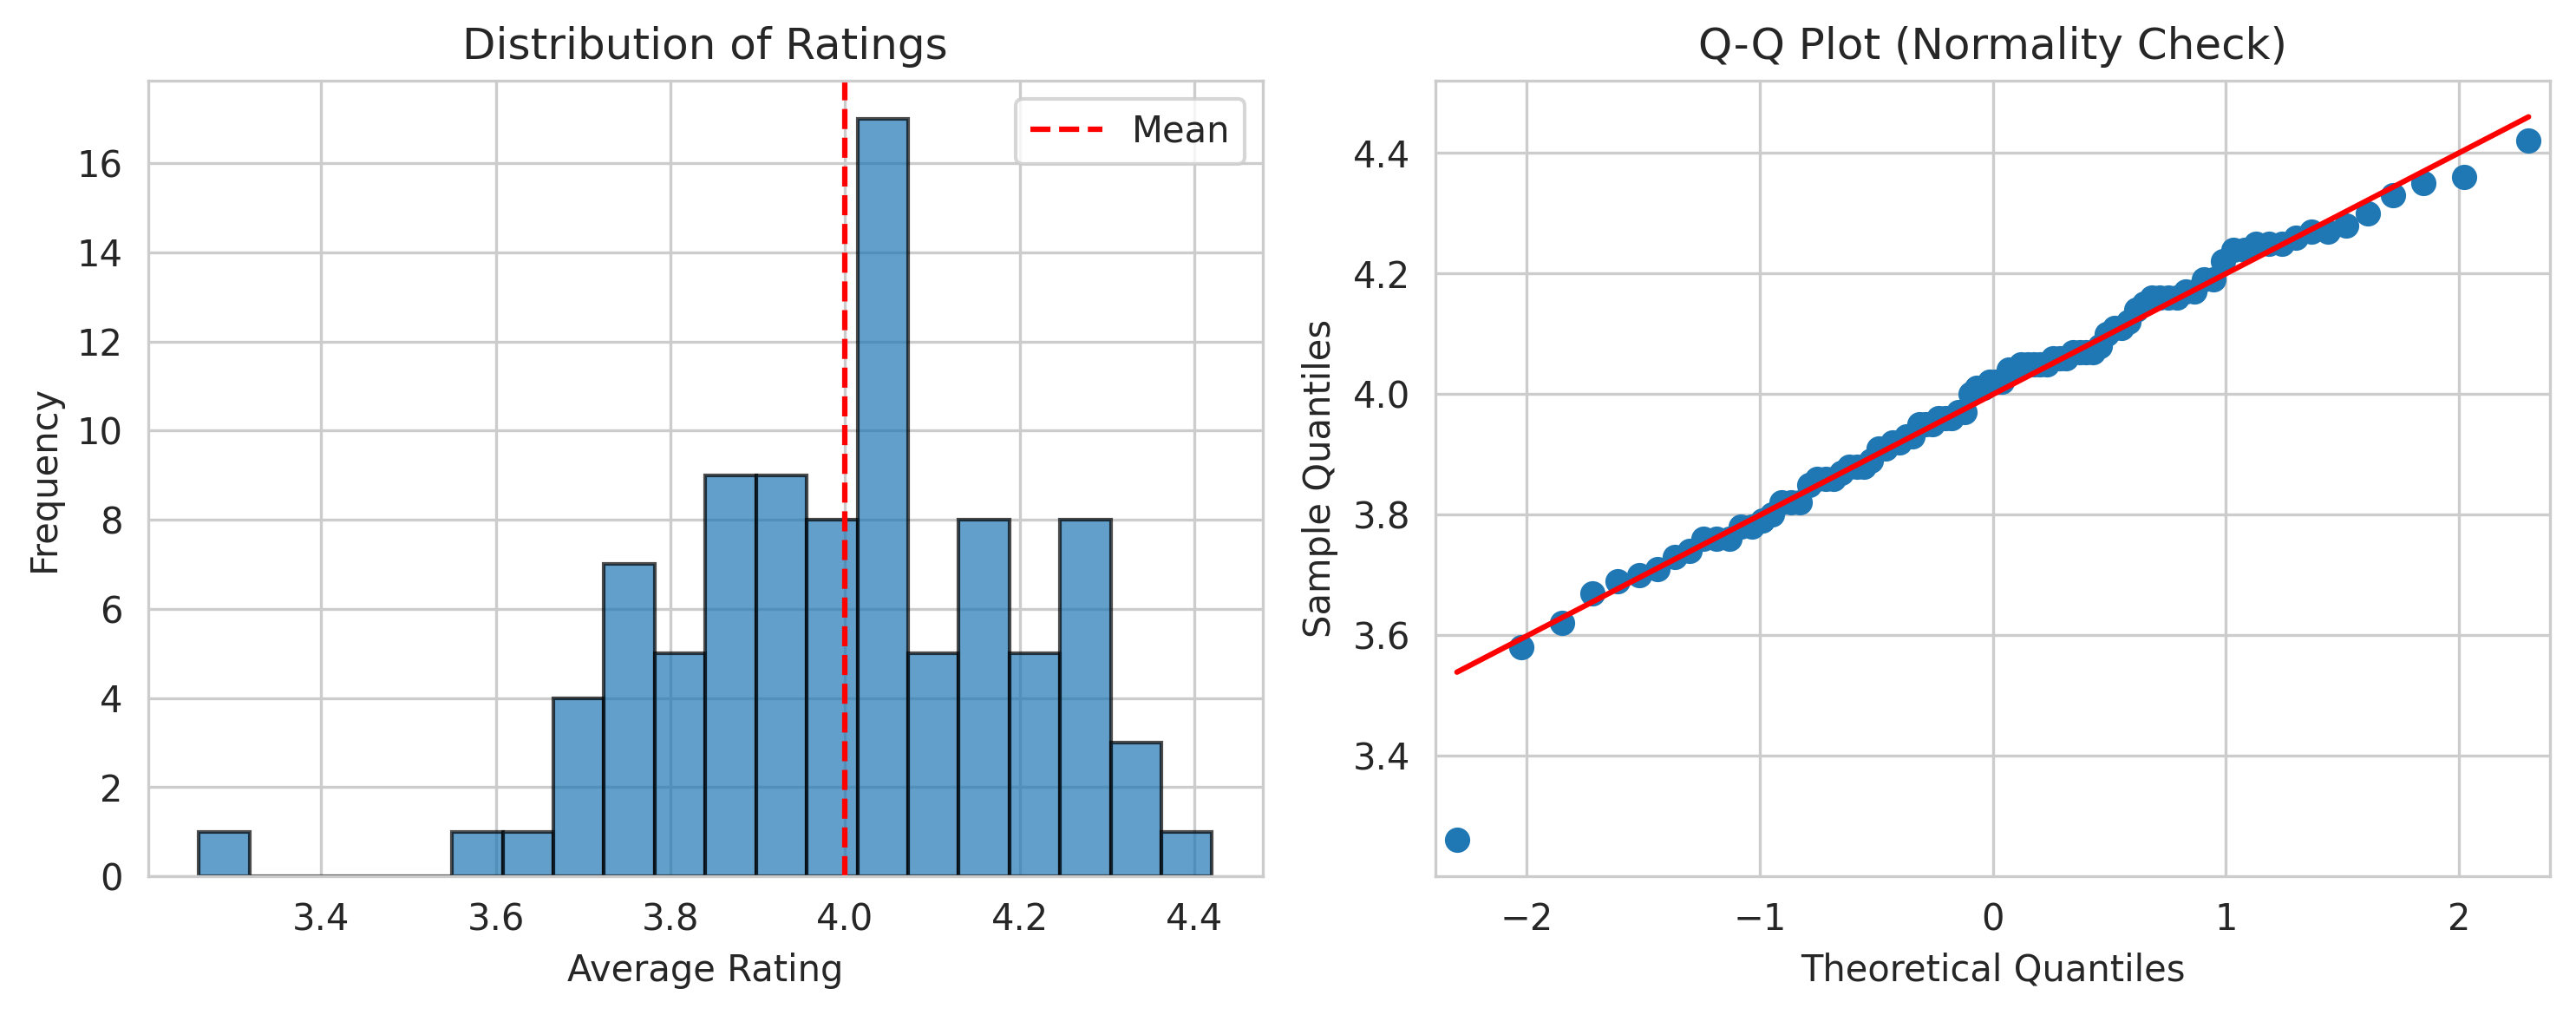

In [6]:
# ============================================================================
# SECTION 2: DESCRIPTIVE STATISTICS
# ============================================================================

print("\n" + "="*70)
print("DESCRIPTIVE STATISTICS")
print("="*70)

# ──────────────────────────────────────────────────────────────
# 2.1 Outcome Variable Distribution
# ──────────────────────────────────────────────────────────────

print(f"\n📊 Outcome Variable: {OUTCOME}")
print(analysis_df[OUTCOME].describe())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Histogram
axes[0].hist(analysis_df[OUTCOME].dropna(), bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(analysis_df[OUTCOME].mean(), color='red', linestyle='--', label='Mean')
axes[0].set_xlabel('Average Rating')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Ratings')
axes[0].legend()

# Q-Q plot (normality check)
sm.qqplot(analysis_df[OUTCOME].dropna(), line='s', ax=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_outcome_distribution.png")
print(f"✓ Saved: 01_outcome_distribution.png")

# Normality test
_, p_shapiro = stats.shapiro(analysis_df[OUTCOME].dropna())
print(f"\nShapiro-Wilk test: p = {p_shapiro:.4f}")
if p_shapiro < 0.05:
    print("  ⚠️  Ratings may not be normally distributed")
    print("     → Consider robust regression or transformations")



📊 Key Predictor Summary:
                                 count      mean       std       min  \
A1_commitment_vows_END            92.0  0.006279  0.014182  0.000015   
B2_emotional_intimacy_END         92.0  0.011763  0.014243  0.000031   
C_explicit_eroticism_END          92.0  0.109802  0.082917  0.010065   
D_power_wealth_luxury_END         92.0  0.078042  0.056349  0.002623   
E_coercion_brutality_danger_END   92.0  0.009467  0.012389  0.000545   
H1_love_over_sex_log_END          92.0  0.469508  0.933374 -1.061932   

                                      25%       50%       75%       max  
A1_commitment_vows_END           0.000383  0.000701  0.003789  0.082802  
B2_emotional_intimacy_END        0.001741  0.003392  0.019220  0.062368  
C_explicit_eroticism_END         0.053136  0.094174  0.125529  0.513967  
D_power_wealth_luxury_END        0.044337  0.072563  0.096820  0.344406  
E_coercion_brutality_danger_END  0.003775  0.005055  0.007661  0.066638  
H1_love_over_sex_log_END 

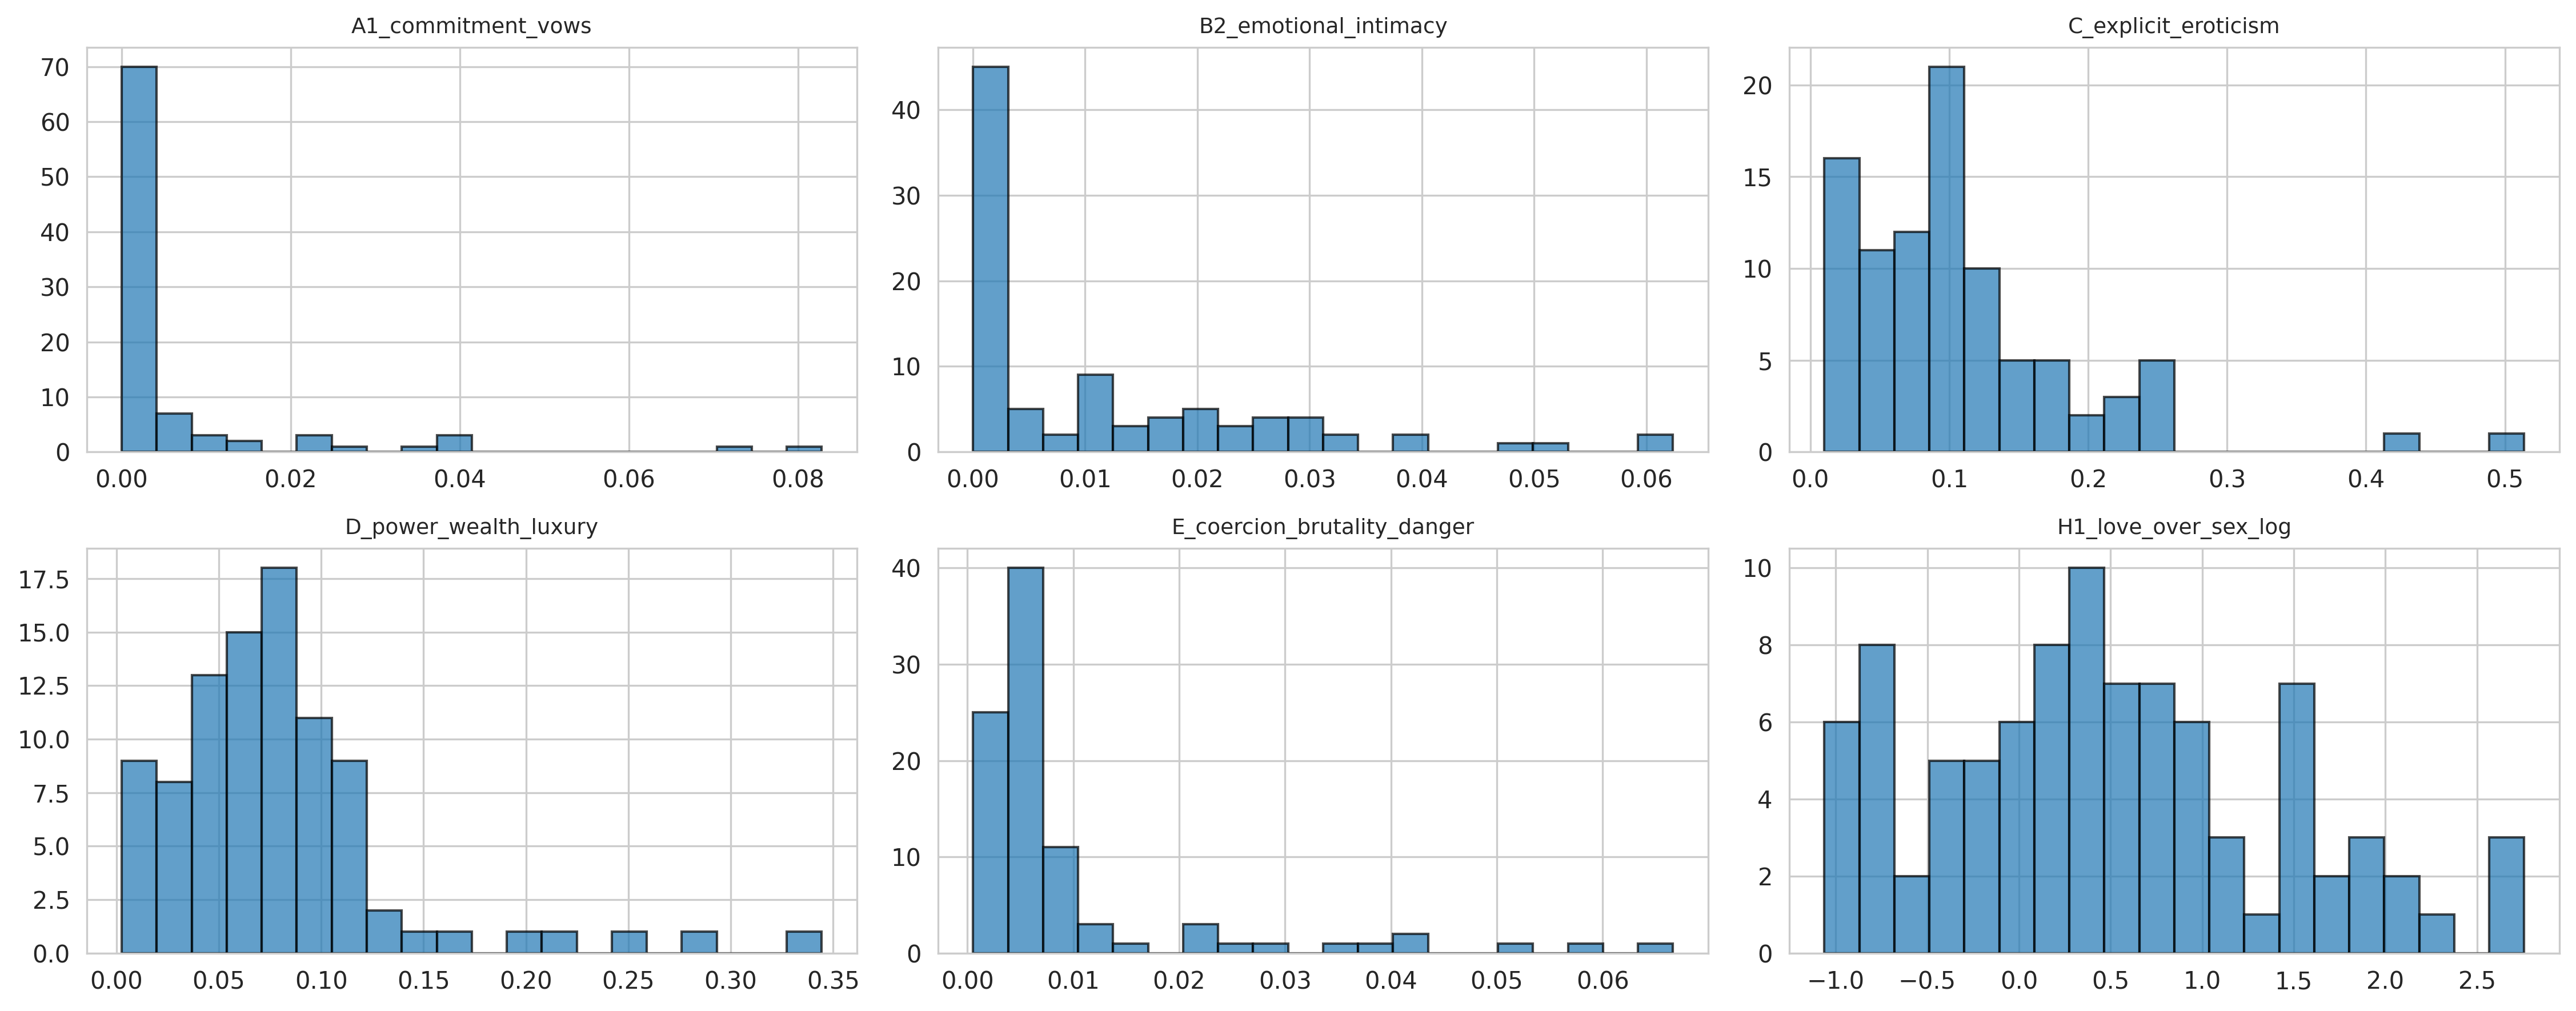

In [7]:
# ──────────────────────────────────────────────────────────────
# 2.2 Predictor Distributions
# ──────────────────────────────────────────────────────────────

print(f"\n📊 Key Predictor Summary:")

# Select key predictors
key_preds = [
    ALL_VARS.get('A1'),
    ALL_VARS.get('B2'),
    ALL_VARS.get('C'),
    ALL_VARS.get('D'),
    ALL_VARS.get('E'),
    ALL_VARS.get('H1_love_sex'),
]
key_preds = [p for p in key_preds if p and p in analysis_df.columns]

print(analysis_df[key_preds].describe().T)

# Distribution plots
n_preds = len(key_preds)
fig, axes = plt.subplots((n_preds + 2) // 3, 3, figsize=(15, 3 * ((n_preds + 2) // 3)))
axes = axes.flatten()

for i, var in enumerate(key_preds):
    axes[i].hist(analysis_df[var].dropna(), bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(var.replace('_END', ''), fontsize=9)
    axes[i].set_xlabel('')

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_predictor_distributions.png")
print(f"✓ Saved: 03_predictor_distributions.png")



📊 Correlation Matrix:
✓ Saved: 04_correlation_matrix.png


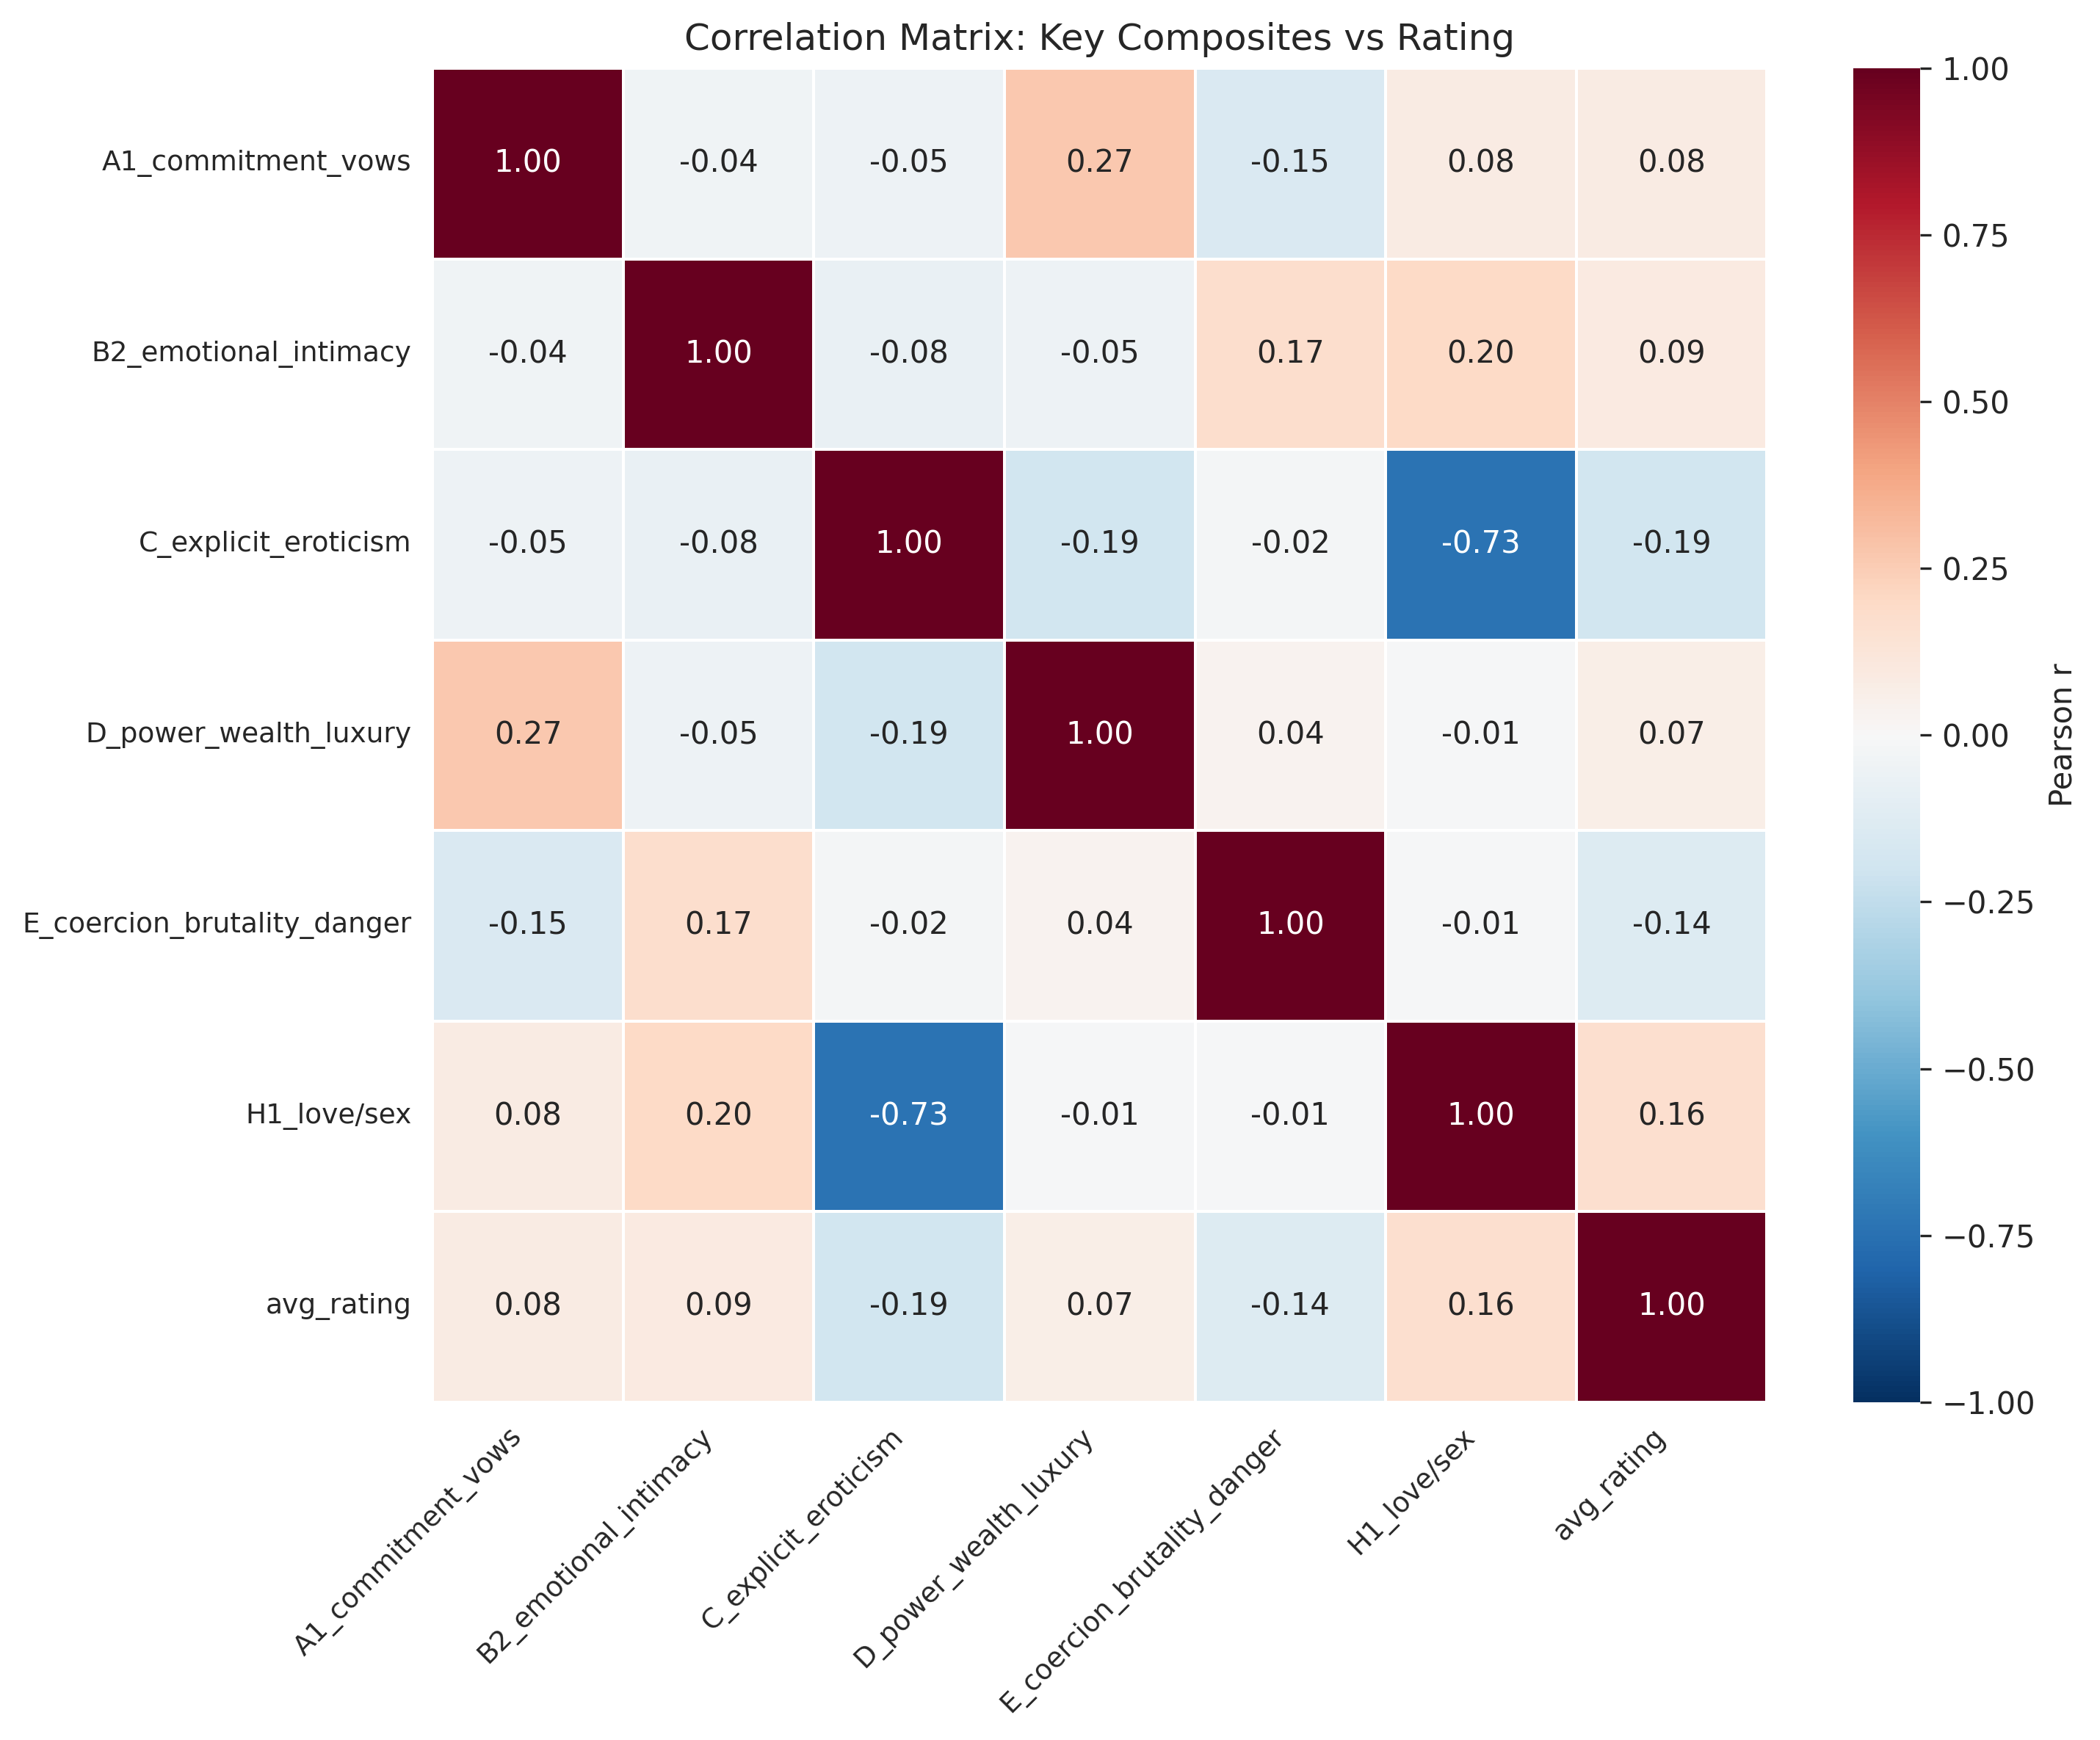

In [8]:
# ──────────────────────────────────────────────────────────────
# 2.3 Correlation Matrix (Key Predictors)
# ──────────────────────────────────────────────────────────────

print(f"\n📊 Correlation Matrix:")

corr_vars = key_preds + [OUTCOME]
corr_matrix = analysis_df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Pearson r'}
)
ax.set_title('Correlation Matrix: Key Composites vs Rating')

# Shorten labels
labels = [l.get_text().replace('_END', '').replace('_over_', '/').replace('_log', '') 
          for l in ax.get_xticklabels()]
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(labels, rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_correlation_matrix.png")
print(f"✓ Saved: 04_correlation_matrix.png")


### SECTION 3: HYPOTHESIS TESTING (BOOK-LEVEL)


In [9]:
# ============================================================================
# SECTION 3: HYPOTHESIS TESTING (BOOK-LEVEL)
# ============================================================================

print("\n" + "="*70)
print("HYPOTHESIS TESTING (BOOK-LEVEL)")
print("="*70)

# Results storage
results = []

# ──────────────────────────────────────────────────────────────
# H1: LOVE-OVER-SEX BALANCE
# ──────────────────────────────────────────────────────────────

print("\n" + "─"*70)
print("H1: Love-Over-Sex Balance")
print("─"*70)

h1_tests = {
    'H1a_vows_vs_sex': ALL_VARS.get('H1_vows_sex'),
    'H1b_safety_vs_sex': ALL_VARS.get('H1_tender_sex'),  # A2+A3
    'H1c_chemistry_vs_sex': ALL_VARS.get('H1_chemistry_sex'),  # B1
    'H1d_intimacy_vs_sex': ALL_VARS.get('B2'),  # Direct use
    'H1e_combined': ALL_VARS.get('H1_love_sex'),  # (A+B)/C
}

for name, var in h1_tests.items():
    if not var or var not in analysis_df.columns:
        print(f"\n⚠️  {name}: Variable '{var}' not available")
        continue
    
    print(f"\n{name}: {var}")
    
    # Bivariate correlation
    data = analysis_df[[var, OUTCOME]].dropna()
    r, p = pearsonr(data[var], data[OUTCOME])
    
    print(f"  Pearson r = {r:+.3f} (p = {p:.4f}, n = {len(data)})")
    
    results.append({
        'hypothesis': name,
        'variable': var,
        'r': r,
        'p': p,
        'n': len(data),
        'sig': '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    })

# Regression: Control for explicitness
print(f"\n📊 Multivariate Test: Controlling for Explicitness")

h1_primary = ALL_VARS.get('H1_love_sex')
explicit = ALL_VARS.get('C')

if h1_primary and explicit and h1_primary in analysis_df.columns and explicit in analysis_df.columns:
    X = analysis_df[[h1_primary, explicit]].dropna()
    y = analysis_df.loc[X.index, OUTCOME]
    
    # Standardize
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
    
    # OLS
    X_with_const = sm.add_constant(X_scaled_df)
    model_h1 = sm.OLS(y, X_with_const).fit()
    
    print(model_h1.summary().tables[1])
    
    results.append({
        'hypothesis': 'H1e_multivariate',
        'variable': f"{h1_primary} + {explicit}",
        'β_love_sex': model_h1.params[h1_primary],
        'β_explicit': model_h1.params[explicit],
        'R²': model_h1.rsquared,
        'p_model': model_h1.f_pvalue
    })



HYPOTHESIS TESTING (BOOK-LEVEL)

──────────────────────────────────────────────────────────────────────
H1: Love-Over-Sex Balance
──────────────────────────────────────────────────────────────────────

H1a_vows_vs_sex: H1_vows_over_sex_log_END
  Pearson r = +0.220 (p = 0.0352, n = 92)

H1b_safety_vs_sex: H1_tender_over_sex_log_END
  Pearson r = +0.202 (p = 0.0541, n = 92)

H1c_chemistry_vs_sex: H1_chemistry_over_sex_log_END
  Pearson r = +0.136 (p = 0.1967, n = 92)

H1d_intimacy_vs_sex: B2_emotional_intimacy_END
  Pearson r = +0.087 (p = 0.4113, n = 92)

H1e_combined: H1_love_over_sex_log_END
  Pearson r = +0.165 (p = 0.1166, n = 92)

📊 Multivariate Test: Controlling for Explicitness
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        3.9993      0.021    192.032      0.000       3.958       4.041
H1_love_over_sex_log_END   

In [10]:
# ──────────────────────────────────────────────────────────────
# H2: HEA INDEX (Commitment)
# ──────────────────────────────────────────────────────────────

print("\n" + "─"*70)
print("H2: HEA Index (Commitment Language)")
print("─"*70)

h2_primary = ALL_VARS.get('A1')  # A1_commitment_vows_END
h2_secondary = ALL_VARS.get('G')  # G_courtship_rituals_END

if h2_primary and h2_primary in analysis_df.columns:
    data = analysis_df[[h2_primary, OUTCOME]].dropna()
    r, p = pearsonr(data[h2_primary], data[OUTCOME])
    
    print(f"\nA1 (Commitment/Vows):")
    print(f"  r = {r:+.3f} (p = {p:.4f}, n = {len(data)})")
    
    results.append({
        'hypothesis': 'H2_commitment',
        'variable': h2_primary,
        'r': r,
        'p': p,
        'n': len(data),
        'sig': '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    })
    
    # Test if courtship rituals add value
    if h2_secondary and h2_secondary in analysis_df.columns:
        print(f"\n📊 Does Courtship (G) add predictive power?")
        
        X = analysis_df[[h2_primary, h2_secondary]].dropna()
        y = analysis_df.loc[X.index, OUTCOME]
        
        # Create interaction
        X['A1_x_G'] = X[h2_primary] * X[h2_secondary]
        
        # Standardize
        X_scaled = scaler.fit_transform(X)
        X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
        
        model_h2 = sm.OLS(y, sm.add_constant(X_scaled_df)).fit()
        print(model_h2.summary().tables[1])
        
        results.append({
            'hypothesis': 'H2_A1xG_interaction',
            'β_interaction': model_h2.params['A1_x_G'],
            'p_interaction': model_h2.pvalues['A1_x_G'],
            'R²': model_h2.rsquared
        })



──────────────────────────────────────────────────────────────────────
H2: HEA Index (Commitment Language)
──────────────────────────────────────────────────────────────────────

A1 (Commitment/Vows):
  r = +0.083 (p = 0.4290, n = 92)

📊 Does Courtship (G) add predictive power?
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                             3.9993      0.021    188.342      0.000       3.957       4.042
A1_commitment_vows_END            0.0118      0.028      0.426      0.671      -0.043       0.067
G_courtship_rituals_gifts_END     0.0141      0.032      0.447      0.656      -0.049       0.077
A1_x_G                            0.0001      0.038      0.003      0.997      -0.075       0.075



──────────────────────────────────────────────────────────────────────
H3: Luxury × Love Interaction
──────────────────────────────────────────────────────────────────────
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         3.9993      0.021    188.331      0.000       3.957       4.042
D_power_wealth_luxury_END    -0.0164      0.045     -0.363      0.718      -0.106       0.074
H3_love_depth_END            -0.0261      0.037     -0.698      0.487      -0.100       0.048
H3_interaction_END            0.0371      0.050      0.744      0.459      -0.062       0.136

📊 Interpretation:
   Luxury main effect:  β = -0.016 (p = 0.7177)
   Love depth:          β = -0.026 (p = 0.4868)
   Interaction:         β = +0.037 (p = 0.4587)

✓ Saved: 05_H3_luxury_interaction.png


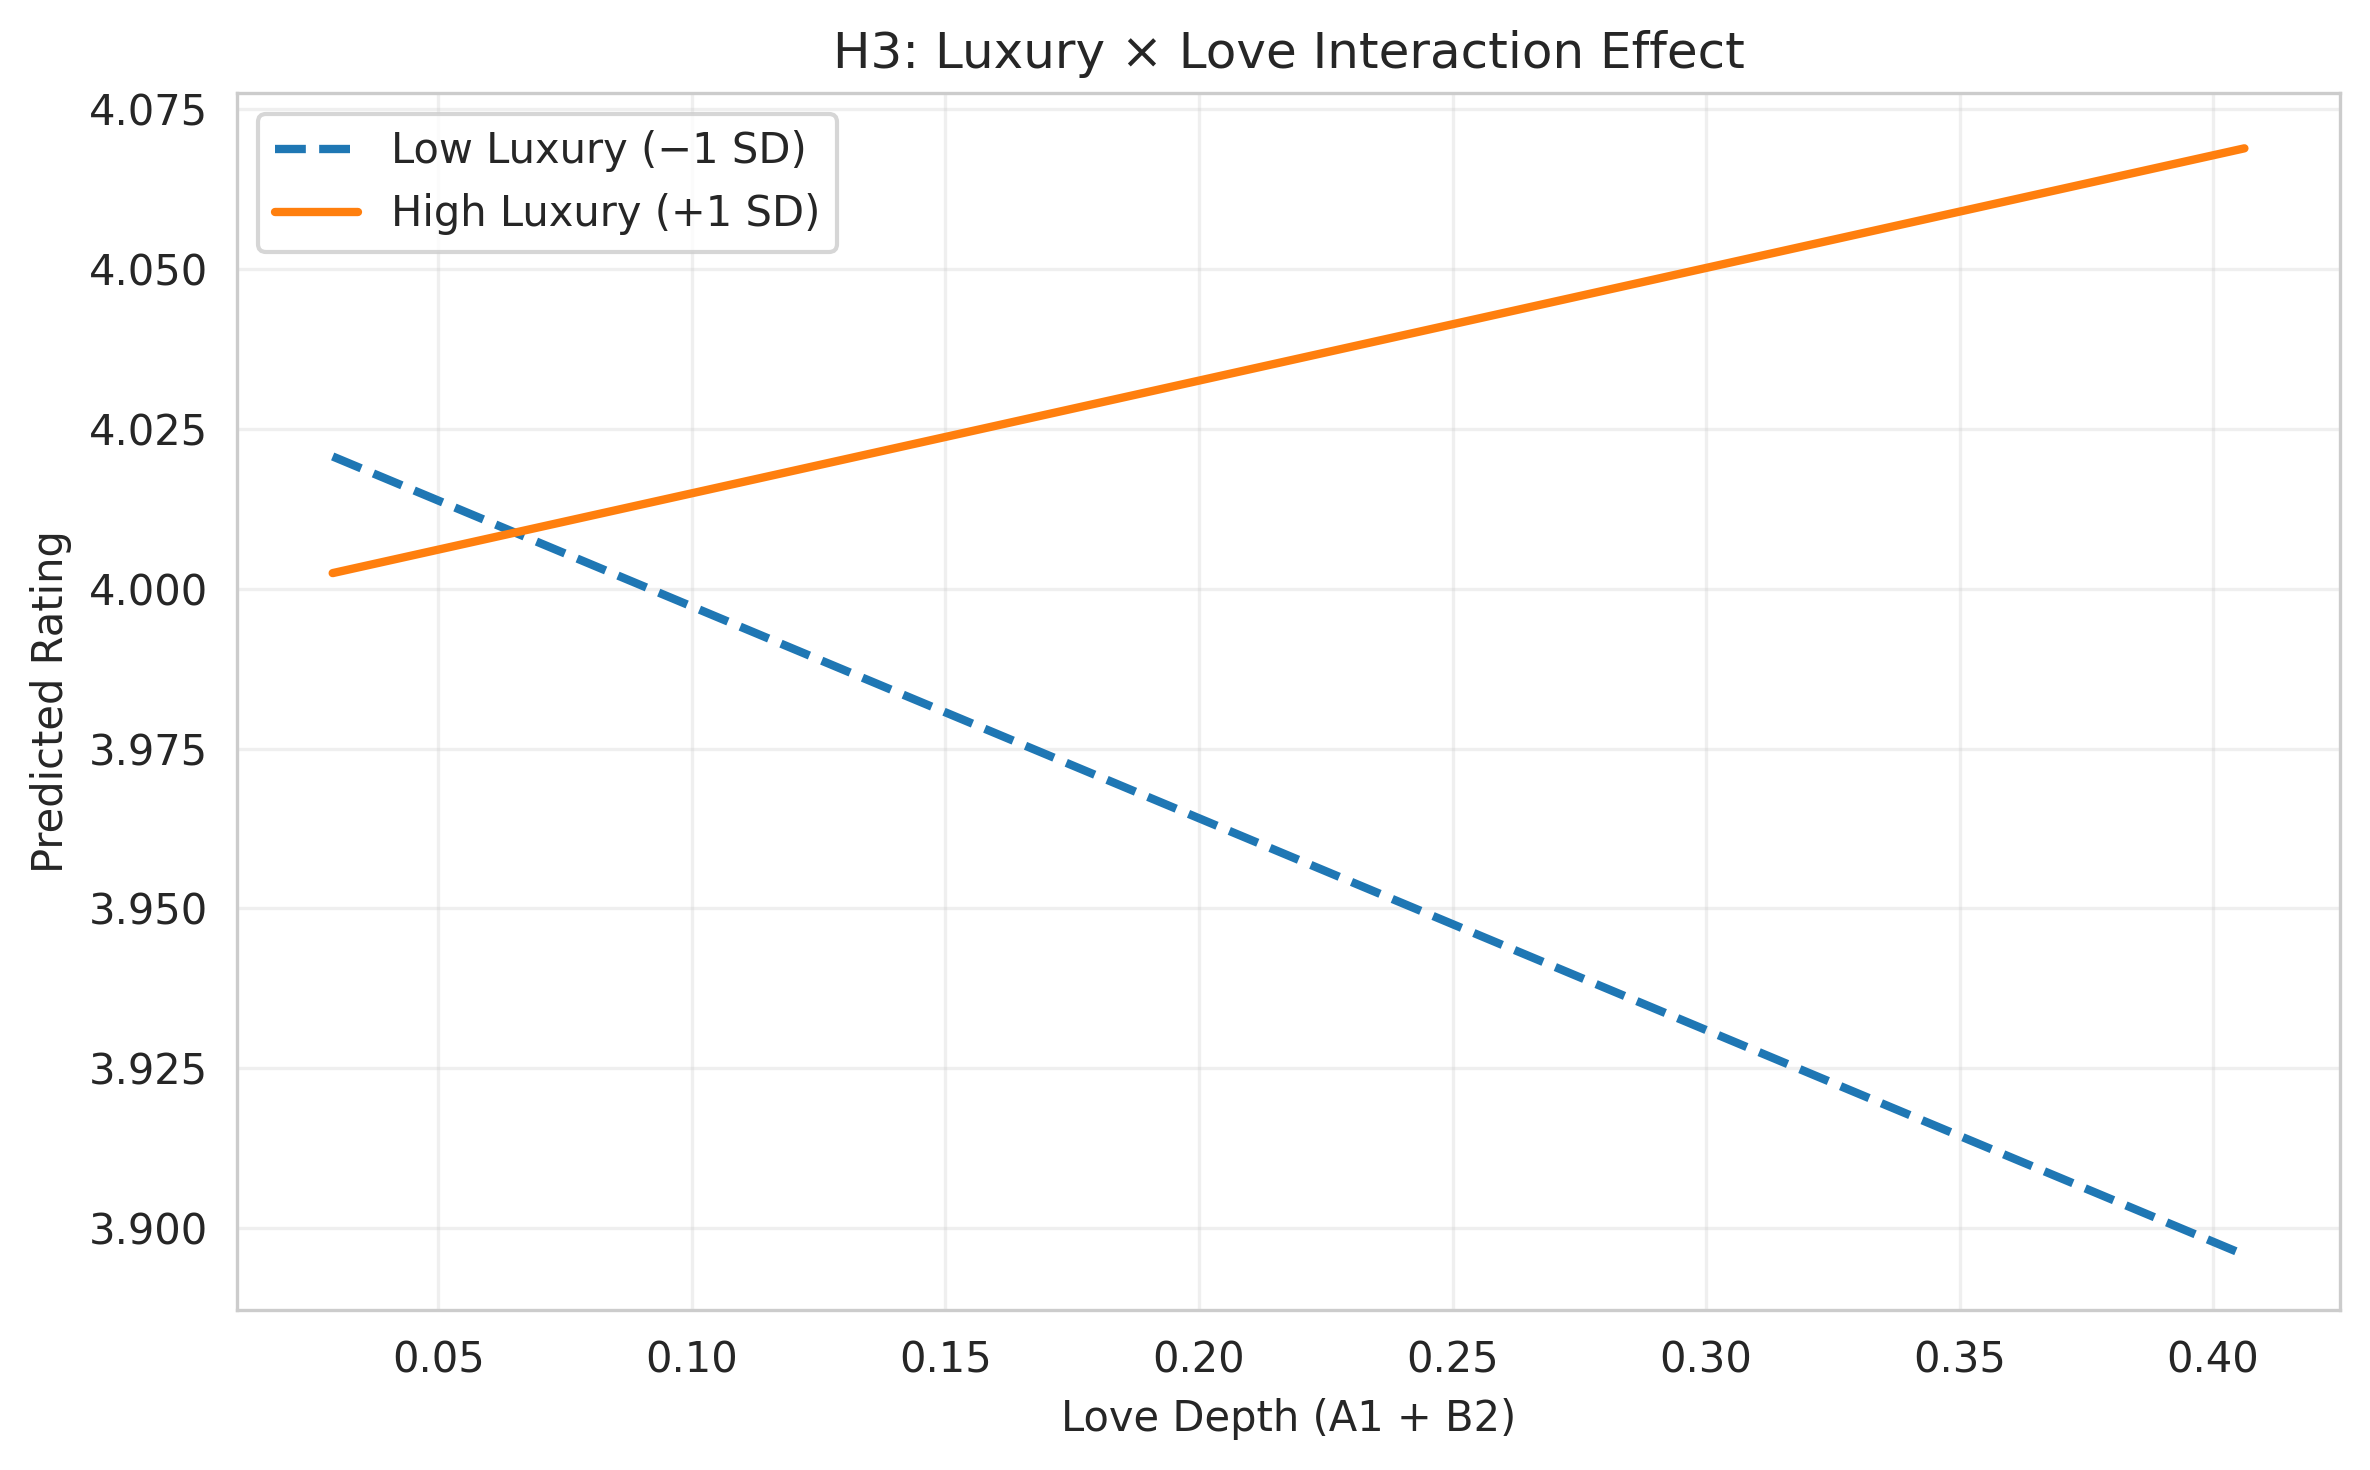

In [11]:
# ──────────────────────────────────────────────────────────────
# H3: LUXURY × LOVE INTERACTION
# ──────────────────────────────────────────────────────────────

print("\n" + "─"*70)
print("H3: Luxury × Love Interaction")
print("─"*70)

h3_luxury = ALL_VARS.get('D')
h3_love = ALL_VARS.get('H3_love_depth')
h3_interaction = ALL_VARS.get('H3_interaction')

# If derived indices not available, create them
if h3_luxury and h3_luxury in analysis_df.columns:
    if not h3_love or h3_love not in analysis_df.columns:
        # Create love depth as sum of available intimacy components
        a1 = ALL_VARS.get('A1')
        a2 = ALL_VARS.get('A2')
        a3 = ALL_VARS.get('A3')
        b1 = ALL_VARS.get('B1')
        b2 = ALL_VARS.get('B2')
        
        # Sum all available components
        components = [a1, a2, a3, b1, b2]
        available = [c for c in components if c and c in analysis_df.columns]
        
        if available:
            analysis_df['H3_love_depth_END'] = analysis_df[available].sum(axis=1)
            h3_love = 'H3_love_depth_END'
            print(f"  ✓ Created H3_love_depth from: {', '.join(available)}")
    
    if not h3_interaction or h3_interaction not in analysis_df.columns:
        if h3_love and h3_love in analysis_df.columns:
            analysis_df['H3_interaction_END'] = analysis_df[h3_luxury] * analysis_df[h3_love]
            h3_interaction = 'H3_interaction_END'
            print(f"  ✓ Created H3_interaction")

if all(v and v in analysis_df.columns for v in [h3_luxury, h3_love, h3_interaction]):
    X = analysis_df[[h3_luxury, h3_love, h3_interaction]].dropna()
    y = analysis_df.loc[X.index, OUTCOME]
    
    # Standardize
    scaler_h3 = StandardScaler()
    X_scaled = scaler_h3.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
    
    # Fit model
    model_h3 = sm.OLS(y, sm.add_constant(X_scaled_df)).fit()
    
    print(model_h3.summary().tables[1])
    
    print(f"\n📊 Interpretation:")
    print(f"   Luxury main effect:  β = {model_h3.params[h3_luxury]:+.3f} (p = {model_h3.pvalues[h3_luxury]:.4f})")
    print(f"   Love depth:          β = {model_h3.params[h3_love]:+.3f} (p = {model_h3.pvalues[h3_love]:.4f})")
    print(f"   Interaction:         β = {model_h3.params[h3_interaction]:+.3f} (p = {model_h3.pvalues[h3_interaction]:.4f})")
    
    if model_h3.pvalues[h3_interaction] < 0.05:
        print(f"\n   ✅ Significant interaction: Luxury amplifies love's effect!")
    
    results.append({
        'hypothesis': 'H3_luxury_interaction',
        'β_luxury': model_h3.params[h3_luxury],
        'β_love': model_h3.params[h3_love],
        'β_interaction': model_h3.params[h3_interaction],
        'p_interaction': model_h3.pvalues[h3_interaction],
        'R²': model_h3.rsquared
    })
    
    # ==============================
    # VISUALIZE INTERACTION (FIXED)
    # ==============================
    luxury_vals = analysis_df[h3_luxury].dropna()
    love_vals = analysis_df[h3_love].dropna()
    
    low_lux = luxury_vals.mean() - luxury_vals.std()
    high_lux = luxury_vals.mean() + luxury_vals.std()
    
    love_range = np.linspace(love_vals.min(), love_vals.max(), 50)
    
    # ✅ FIX: Properly construct prediction data
    def predict_rating(love, luxury):
        """Predict rating at given love/luxury levels."""
        # Create interaction term
        interaction = love * luxury
        
        # Scale the raw values using fitted scaler
        X_new = scaler_h3.transform([[luxury, love, interaction]])
        
        # Convert to DataFrame with proper column names
        X_new_df = pd.DataFrame(X_new, columns=[h3_luxury, h3_love, h3_interaction])
        
        # Add constant (matches model fitting)
        X_new_with_const = sm.add_constant(X_new_df, has_constant='add')
        
        # Predict
        return model_h3.predict(X_new_with_const).iloc[0]
    
    # Generate predictions for plot
    pred_low = []
    pred_high = []
    
    for l in love_range:
        try:
            pred_low.append(predict_rating(l, low_lux))
            pred_high.append(predict_rating(l, high_lux))
        except Exception as e:
            print(f"  ⚠️  Prediction error at love={l:.3f}: {e}")
            pred_low.append(np.nan)
            pred_high.append(np.nan)
    
    # Plot
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(love_range, pred_low, label='Low Luxury (−1 SD)', linestyle='--', linewidth=2)
    ax.plot(love_range, pred_high, label='High Luxury (+1 SD)', linestyle='-', linewidth=2)
    ax.set_xlabel('Love Depth (A1 + B2)')
    ax.set_ylabel('Predicted Rating')
    ax.set_title('H3: Luxury × Love Interaction Effect')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "05_H3_luxury_interaction.png", dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: 05_H3_luxury_interaction.png")
    
else:
    print(f"\n⚠️  H3 variables not available:")
    if not h3_luxury or h3_luxury not in analysis_df.columns:
        print(f"   - Luxury (D) missing")
    if not h3_love or h3_love not in analysis_df.columns:
        print(f"   - Love depth missing")
    if not h3_interaction or h3_interaction not in analysis_df.columns:
        print(f"   - Interaction term missing")

In [12]:
# ──────────────────────────────────────────────────────────────
# H4: PROTECTIVENESS VS POSSESSIVENESS
# ──────────────────────────────────────────────────────────────

print("\n" + "─"*70)
print("H4: Protectiveness vs Possessiveness")
print("─"*70)

h4_tests = {
    'H4a_tender_protect': ALL_VARS.get('R1'),
    'H4b_alpha_guard': ALL_VARS.get('R2'),
    'H4c_balance': ALL_VARS.get('H4_protect_jealous'),
    'H4d_tender_vs_alpha': ALL_VARS.get('H4_tender_alpha'),
}

for name, var in h4_tests.items():
    if not var or var not in analysis_df.columns:
        continue
    
    print(f"\n{name}: {var}")
    data = analysis_df[[var, OUTCOME]].dropna()
    r, p = pearsonr(data[var], data[OUTCOME])
    
    print(f"  r = {r:+.3f} (p = {p:.4f}, n = {len(data)})")
    
    results.append({
        'hypothesis': name,
        'variable': var,
        'r': r,
        'p': p,
        'n': len(data),
        'sig': '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    })

# Test R1 × R2 interaction (tender care amplifies alpha?)
r1 = ALL_VARS.get('R1')
r2 = ALL_VARS.get('R2')

if r1 and r2 and r1 in analysis_df.columns and r2 in analysis_df.columns:
    print(f"\n📊 Interaction: Tender Care × Alpha Guarding")
    
    X = analysis_df[[r1, r2]].dropna()
    X['R1_x_R2'] = X[r1] * X[r2]
    y = analysis_df.loc[X.index, OUTCOME]
    
    model_r = sm.OLS(y, sm.add_constant(scaler.fit_transform(X))).fit()
    print(model_r.summary().tables[1])



──────────────────────────────────────────────────────────────────────
H4: Protectiveness vs Possessiveness
──────────────────────────────────────────────────────────────────────

H4a_tender_protect: R1_protective_caretaking_END
  r = -0.126 (p = 0.2317, n = 92)

H4b_alpha_guard: R2_alpha_guarding_END
  r = +0.133 (p = 0.2047, n = 92)

H4c_balance: H4_protect_over_jealous_log_END
  r = -0.189 (p = 0.0712, n = 92)

H4d_tender_vs_alpha: H4_tender_over_alpha_log_END
  r = -0.134 (p = 0.2015, n = 92)

📊 Interaction: Tender Care × Alpha Guarding
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9993      0.021    191.322      0.000       3.958       4.041
x1            -0.0356      0.024     -1.457      0.149      -0.084       0.013
x2             0.0075      0.027      0.277      0.783      -0.046       0.061
x3             0.0293      0.029      1.008      0.316   

In [13]:
# ──────────────────────────────────────────────────────────────
# H5: DARKNESS VS TENDERNESS
# ──────────────────────────────────────────────────────────────

print("\n" + "─"*70)
print("H5: Darkness vs Tenderness")
print("─"*70)

h5_tests = {
    'H5a_trauma_safety': ALL_VARS.get('H5_trauma_safety'),
    'H5b_anger_intimacy': ALL_VARS.get('H5_anger_tender'),
    'H5c_overall_dark': ALL_VARS.get('H5_dark_tender'),
}

for name, var in h5_tests.items():
    if not var or var not in analysis_df.columns:
        continue
    
    print(f"\n{name}: {var}")
    data = analysis_df[[var, OUTCOME]].dropna()
    r, p = pearsonr(data[var], data[OUTCOME])
    
    print(f"  r = {r:+.3f} (p = {p:.4f}, n = {len(data)})")
    
    results.append({
        'hypothesis': name,
        'variable': var,
        'r': r,
        'p': p,
        'n': len(data),
        'sig': '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    })

# Test quadratic effect (inverted U?)
e_var = ALL_VARS.get('E')
f1_var = ALL_VARS.get('F1')

if e_var and f1_var and e_var in analysis_df.columns and f1_var in analysis_df.columns:
    print(f"\n📊 Quadratic Test: Is there optimal darkness?")
    
    # Create darkness composite
    analysis_df['darkness'] = analysis_df[e_var] + analysis_df[f1_var]
    analysis_df['darkness_sq'] = analysis_df['darkness'] ** 2
    
    X = analysis_df[['darkness', 'darkness_sq']].dropna()
    y = analysis_df.loc[X.index, OUTCOME]
    
    model_quad = sm.OLS(y, sm.add_constant(scaler.fit_transform(X))).fit()
    print(model_quad.summary().tables[1])
    
    if model_quad.pvalues.get('darkness_sq', 1.0) < 0.05:
        if model_quad.params.get('darkness_sq', 0) < 0:
            print(f"\n   ✅ Inverted U detected: Too much darkness hurts ratings")
        else:
            print(f"\n   📈 U-shape: Very low/high darkness both problematic")



──────────────────────────────────────────────────────────────────────
H5: Darkness vs Tenderness
──────────────────────────────────────────────────────────────────────

H5a_trauma_safety: H5_trauma_over_safety_log_END
  r = -0.084 (p = 0.4238, n = 92)

H5b_anger_intimacy: H5_anger_over_tender_log_END
  r = +0.294 (p = 0.0045, n = 92)

H5c_overall_dark: H5_dark_over_tender_log_END
  r = +0.016 (p = 0.8818, n = 92)

📊 Quadratic Test: Is there optimal darkness?
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9993      0.021    190.914      0.000       3.958       4.041
x1            -0.0025      0.057     -0.043      0.966      -0.117       0.112
x2            -0.0306      0.057     -0.532      0.596      -0.145       0.084


### SECTION 4: HYPOTHESIS TESTING (SEGMENT-LEVEL ARCS) — H6



H6: NARRATIVE ARC ANALYSIS (SEGMENT-LEVEL)

✓ Segment dataset: (276, 42)
   Books: 92
   Segments per book: 3.0

──────────────────────────────────────────────────────────────────────
A1 (Commitment): Commitment language should ↑ toward HEA
──────────────────────────────────────────────────────────────────────

  Trajectory: {'begin': 0.006263231736184665, 'end': 0.006278551674021619, 'middle': 0.0032820389718645248}
  Linear trend: r = +0.001 (p = 0.9927)
  ✓ Saved: 06_H6_A1_Commitment_arc.png

──────────────────────────────────────────────────────────────────────
C (Explicit Sex): Sexual content peaks mid-book, resolved by end
──────────────────────────────────────────────────────────────────────

  Trajectory: {'begin': 0.0777421687380918, 'end': 0.10980226239911857, 'middle': 0.13124055421646028}
  Linear trend: r = +0.172 (p = 0.0042)
  ✓ Saved: 06_H6_C_Explicit_Sex_arc.png

──────────────────────────────────────────────────────────────────────
F1 (Grief/Sadness): Emotional pain 

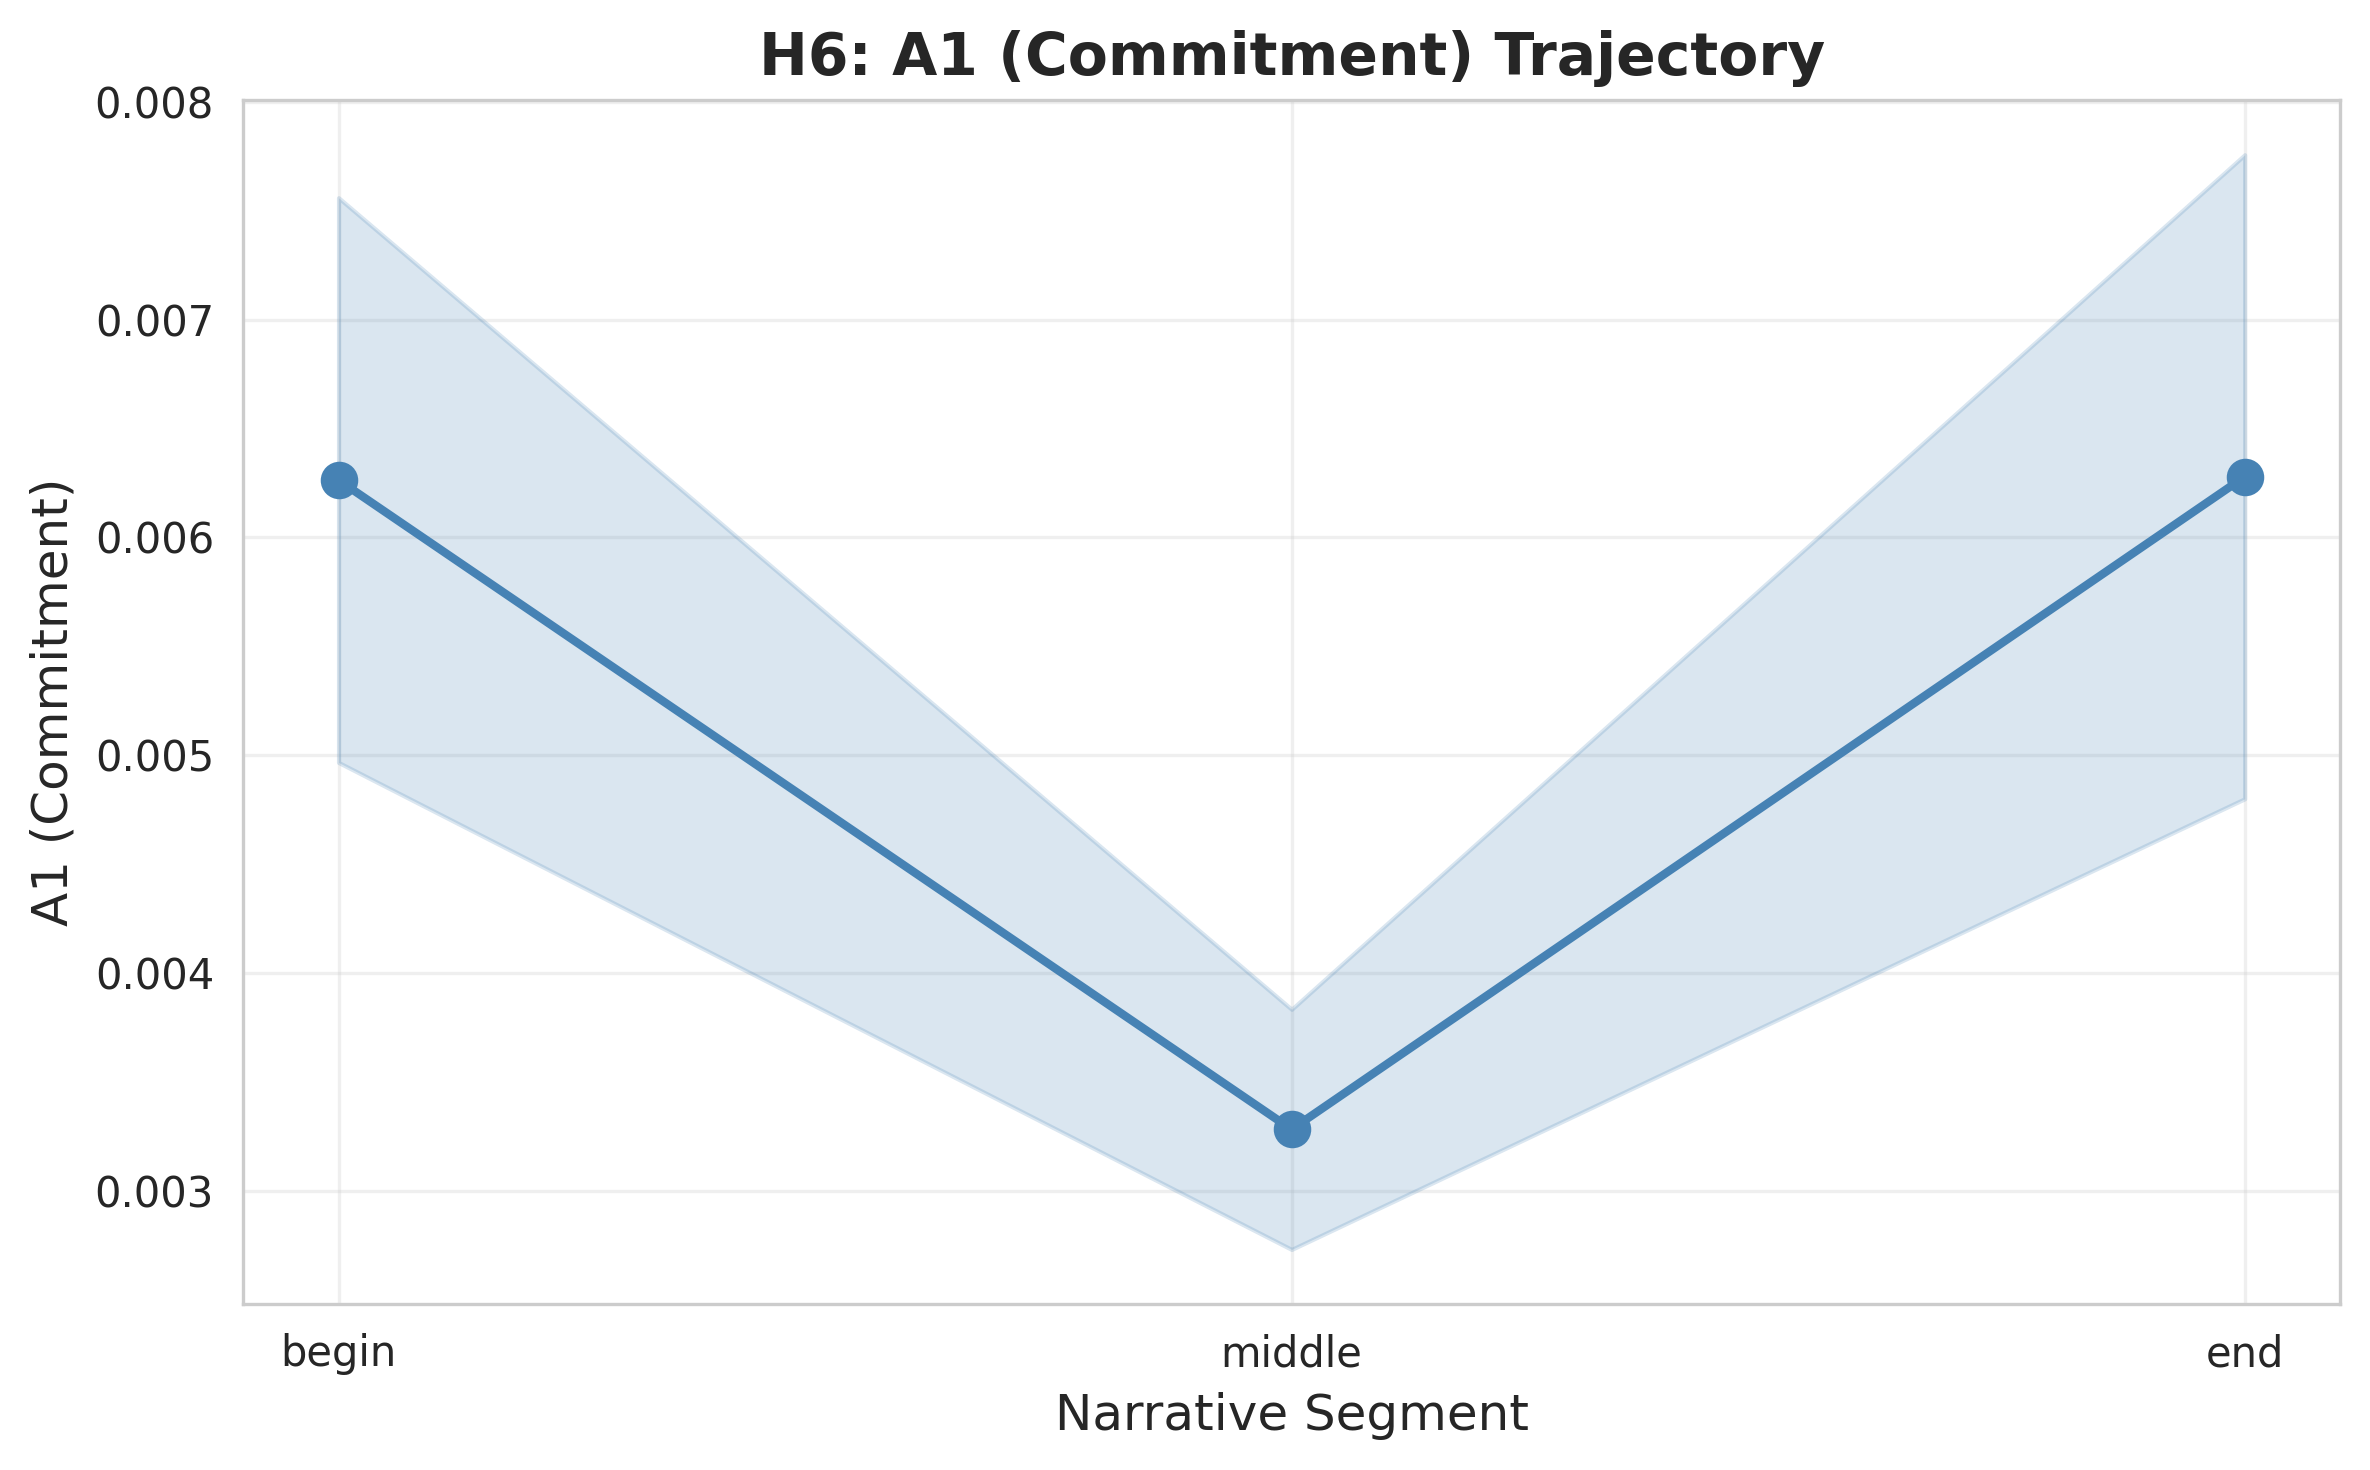

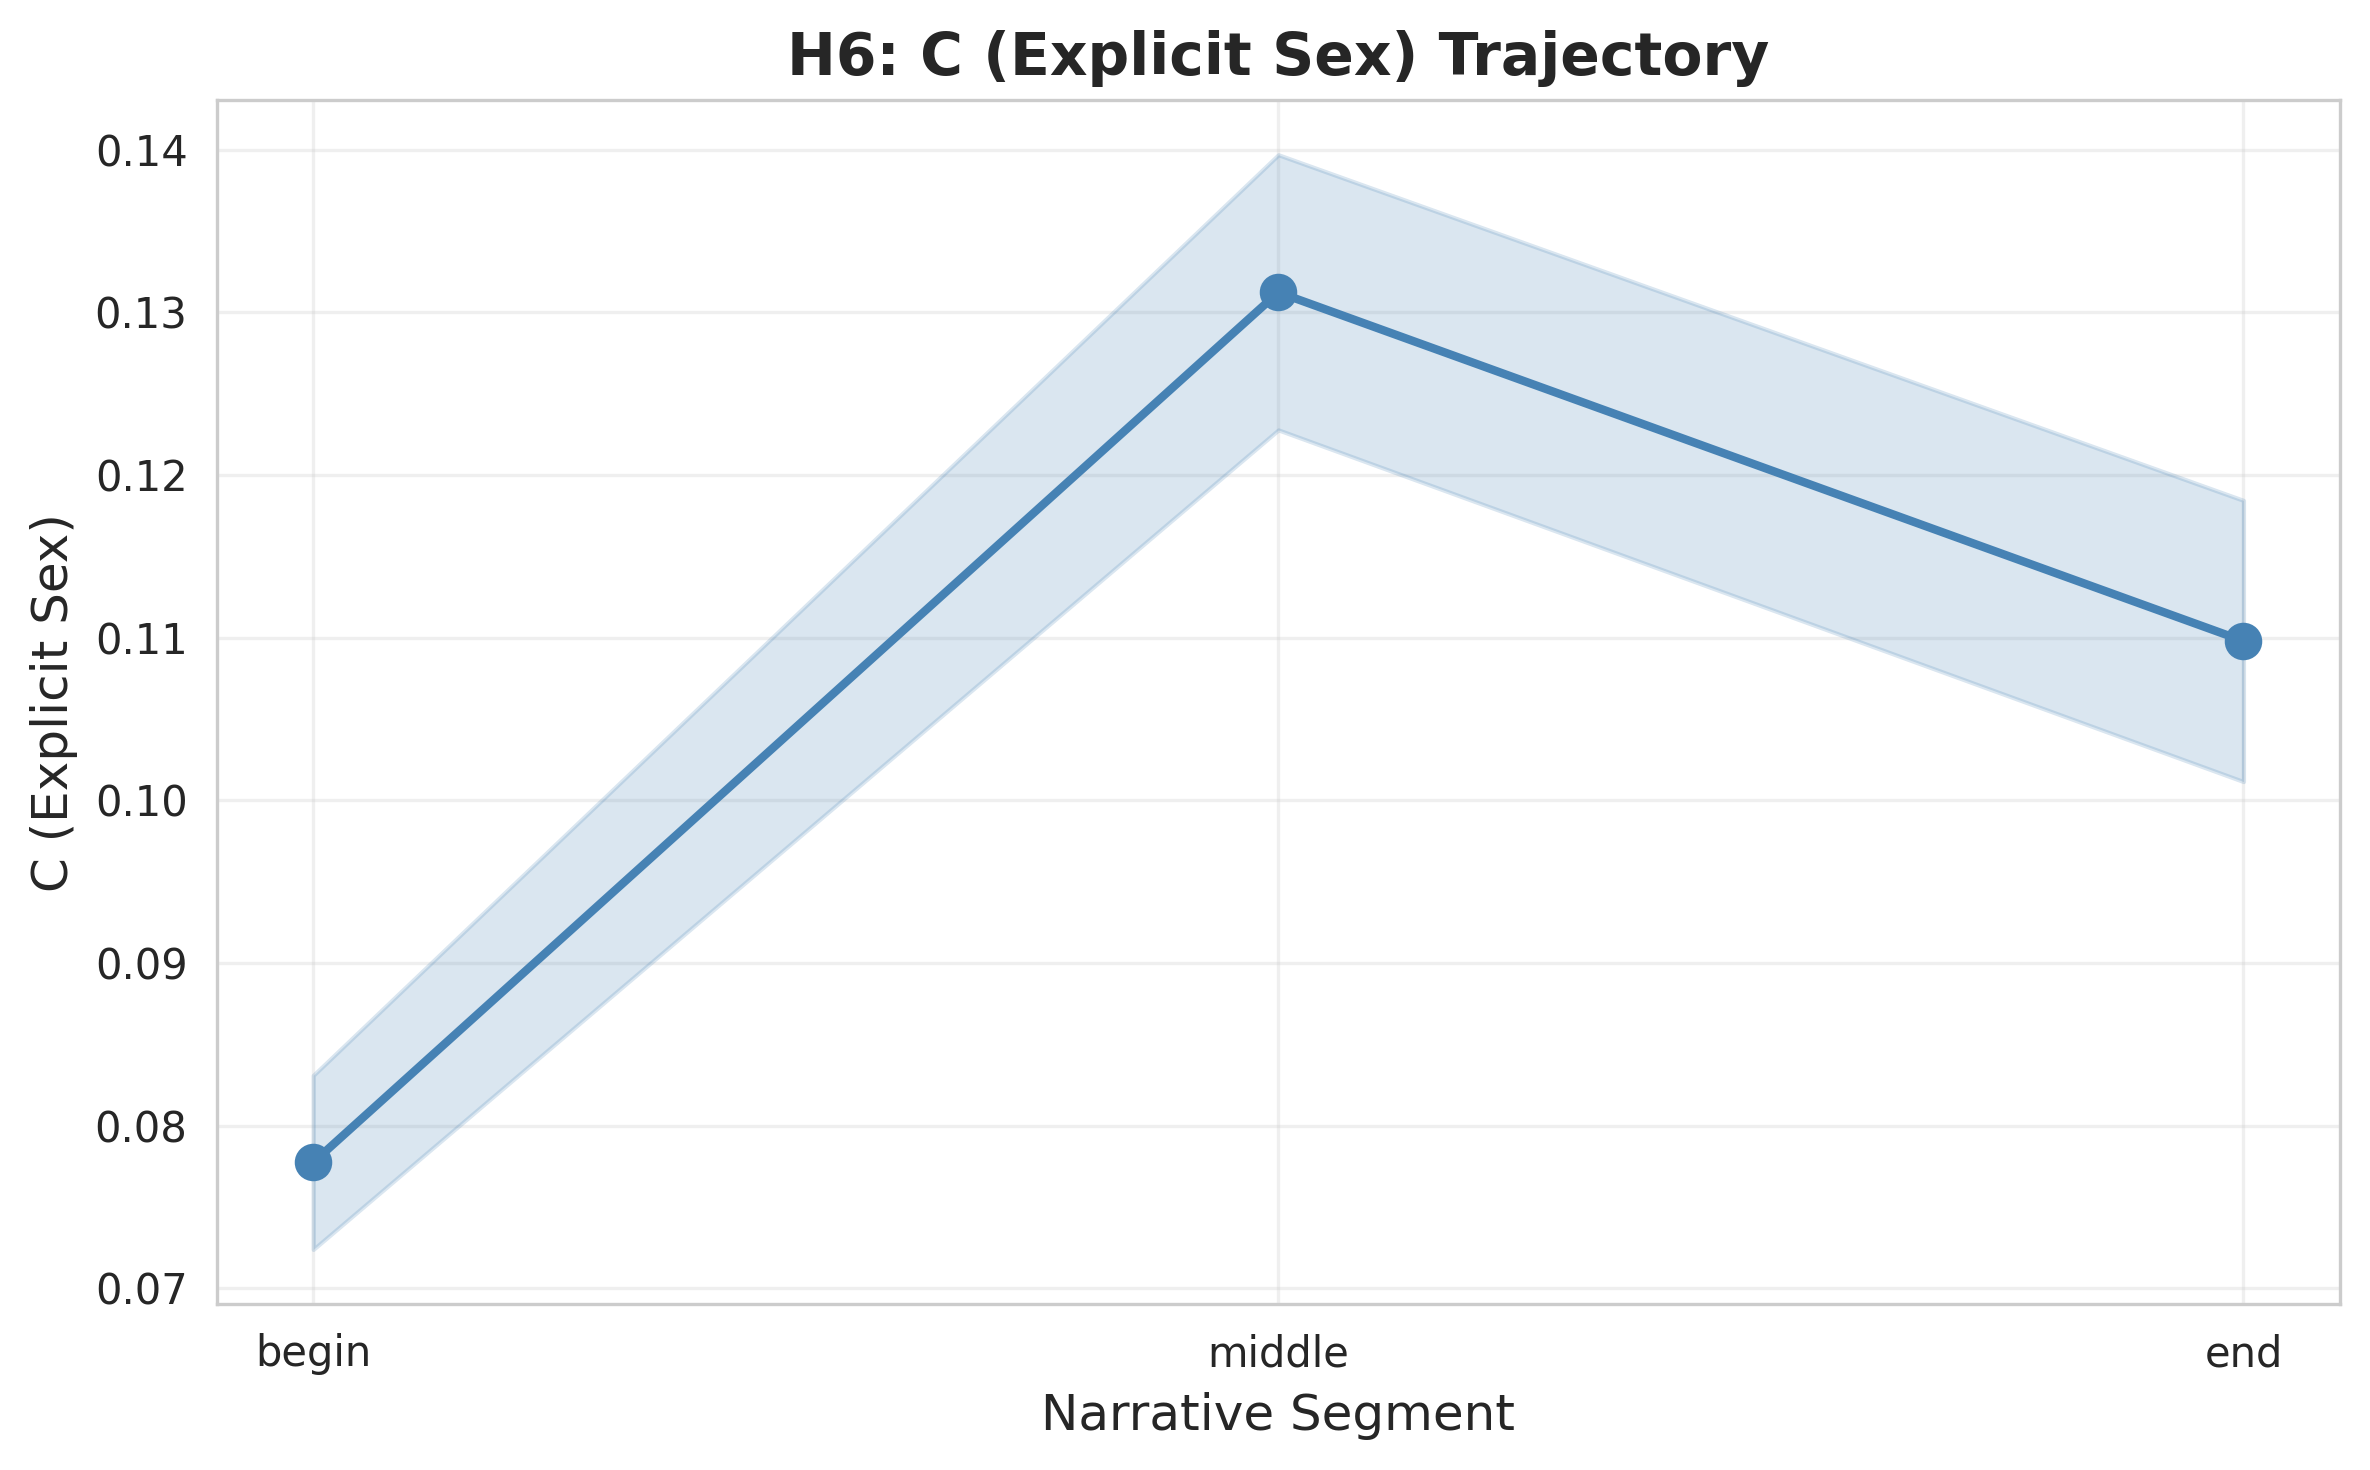

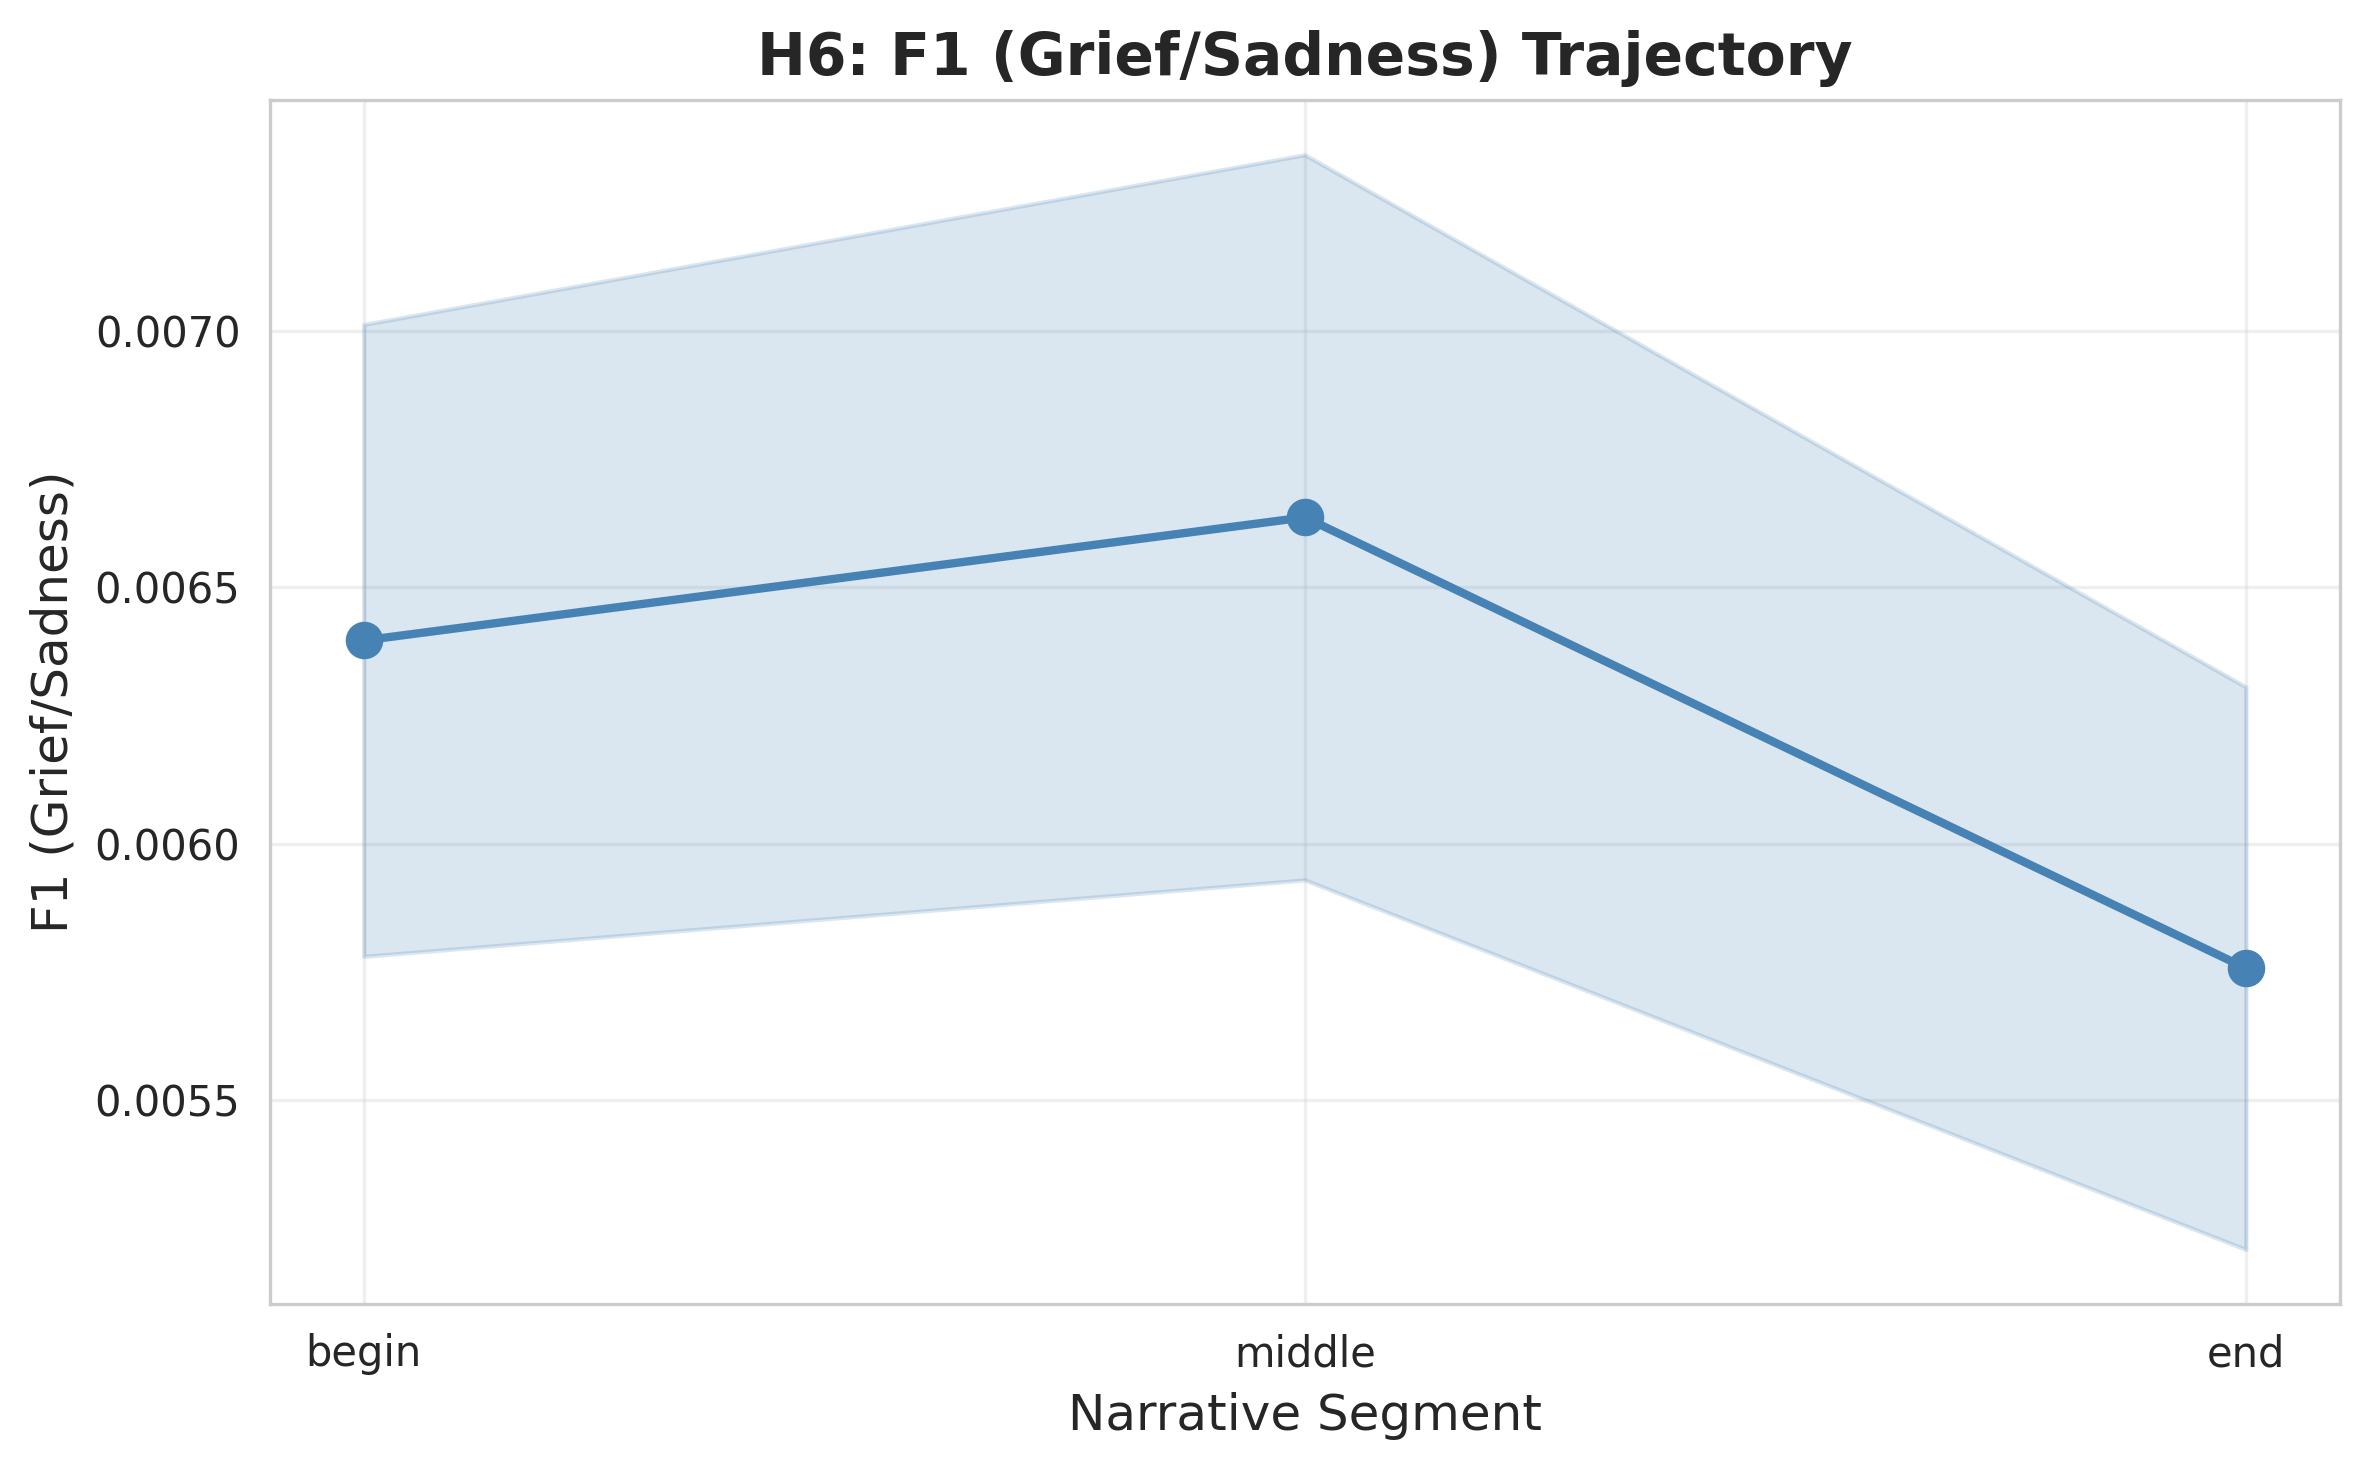

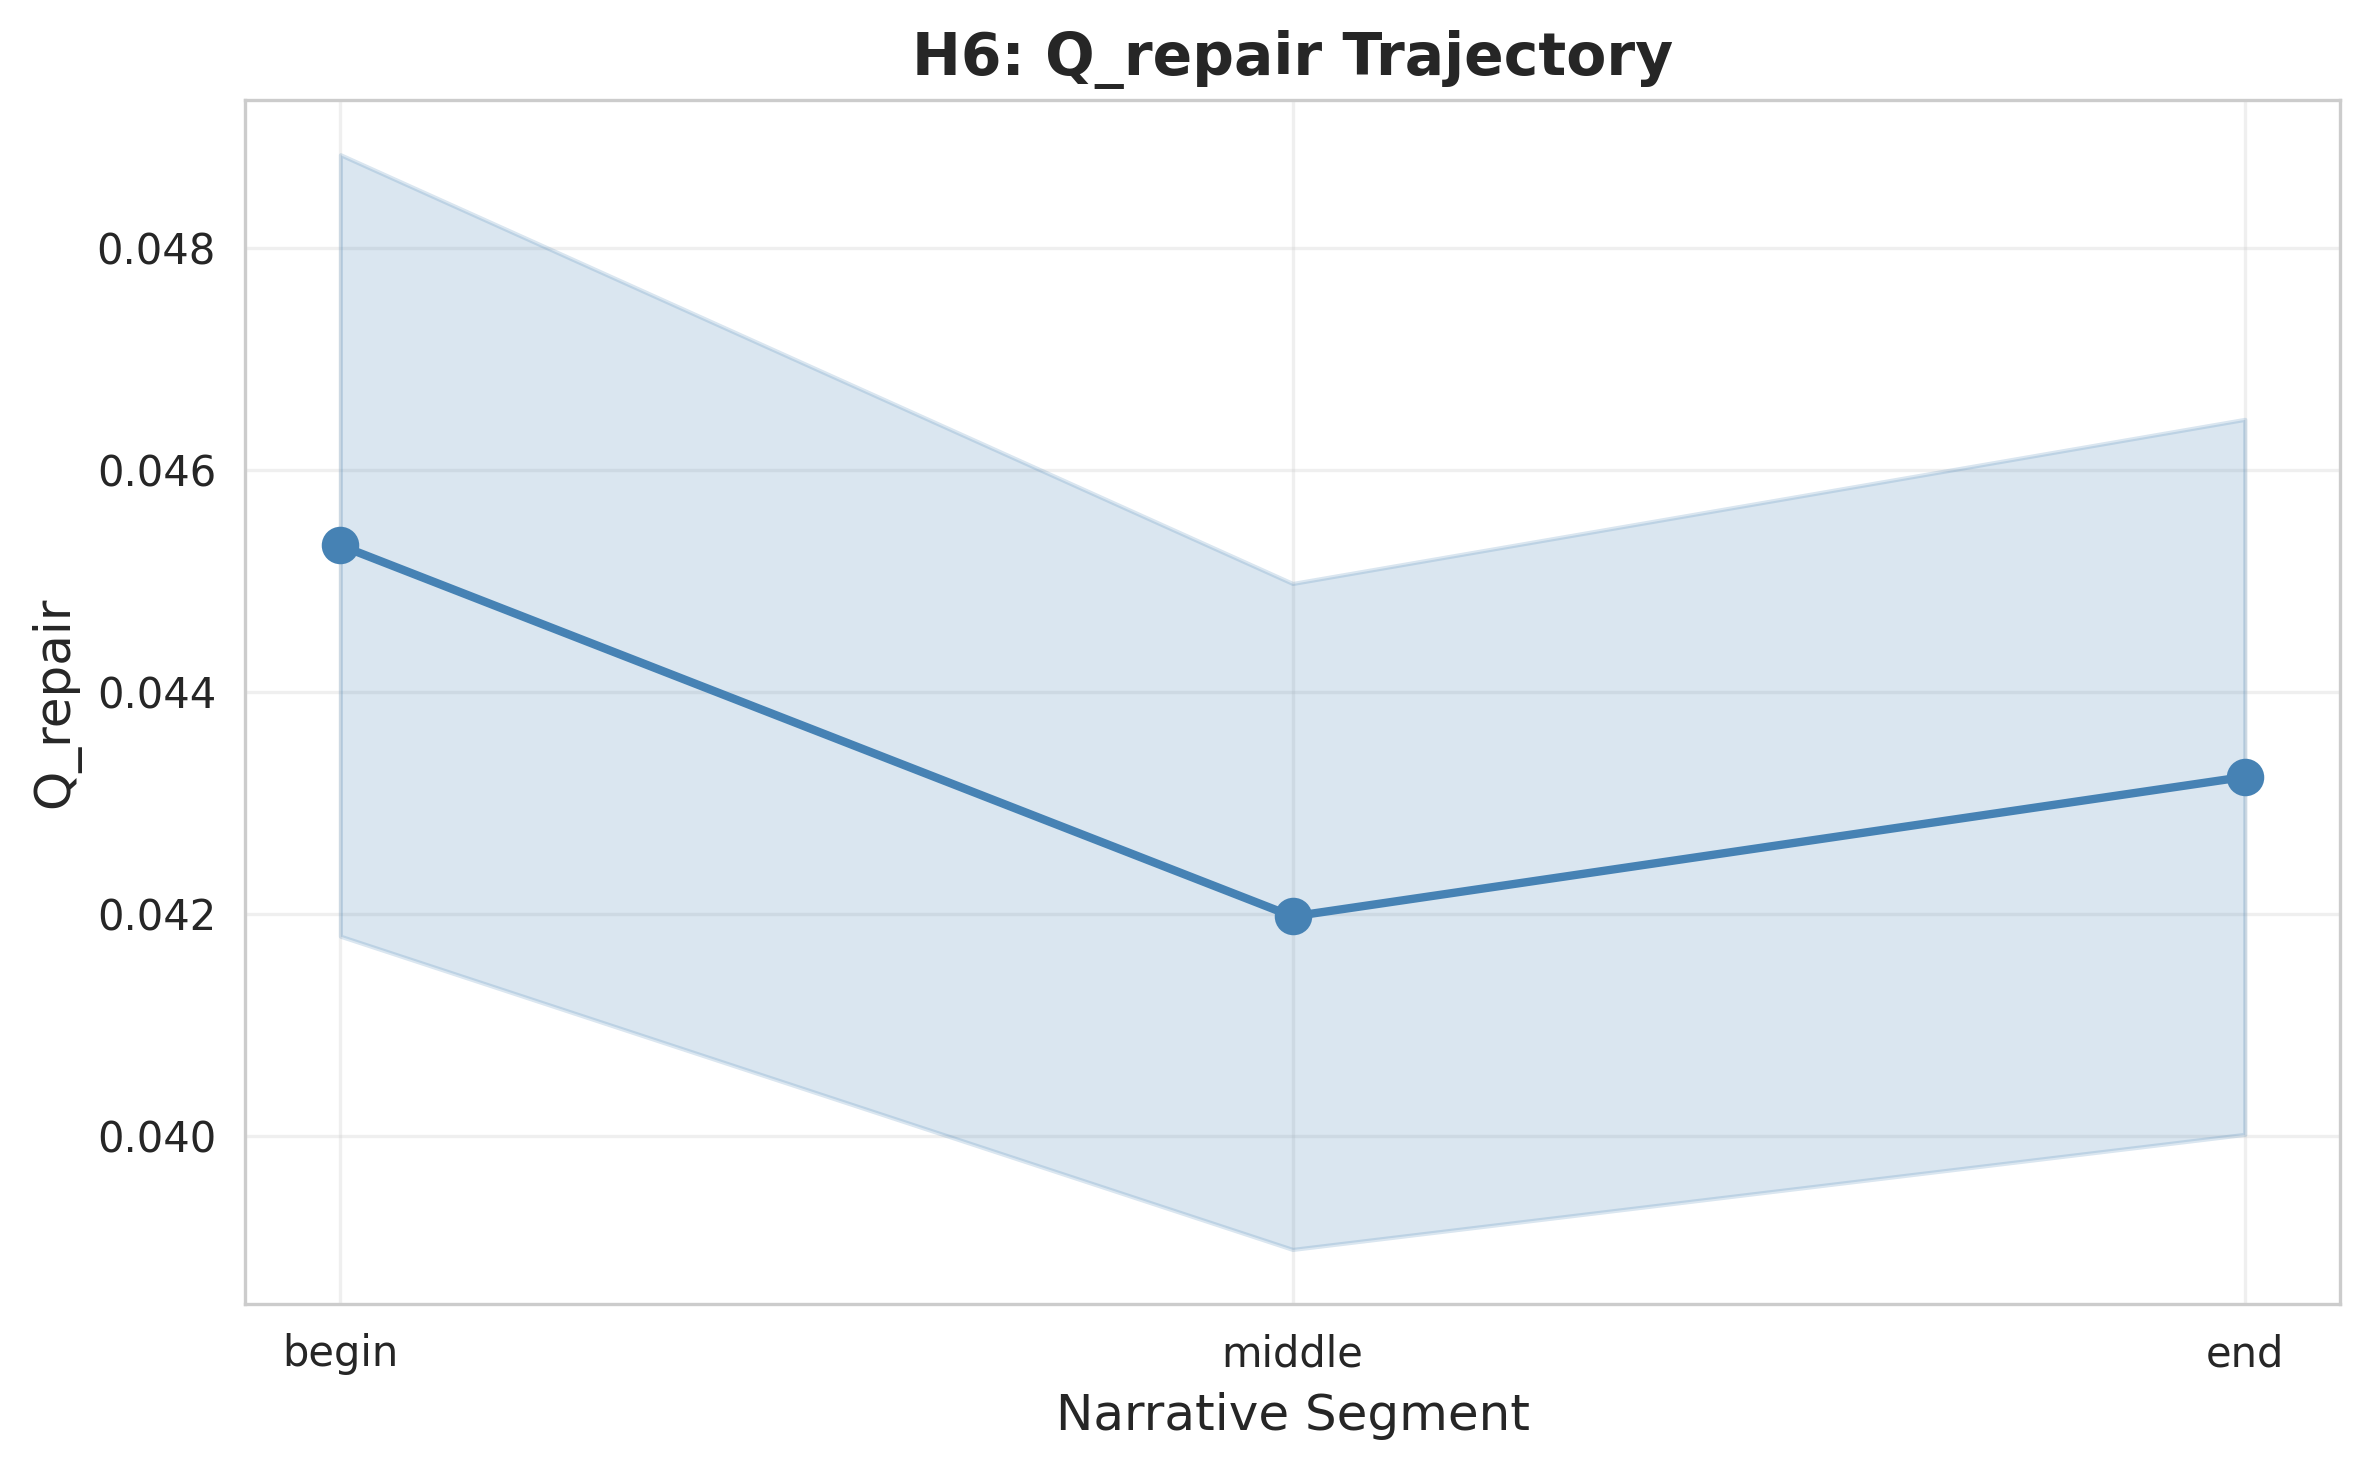

In [14]:
# ============================================================================
# SECTION 4: HYPOTHESIS TESTING (SEGMENT-LEVEL ARCS) — H6
# ============================================================================

print("\n" + "="*70)
print("H6: NARRATIVE ARC ANALYSIS (SEGMENT-LEVEL)")
print("="*70)

# Merge segments with ratings
segments_full = segments.merge(
    ratings[['book_id', OUTCOME]],
    on='book_id',
    how='inner'
)

print(f"\n✓ Segment dataset: {segments_full.shape}")
print(f"   Books: {segments_full['book_id'].nunique()}")
print(f"   Segments per book: {segments_full.groupby('book_id').size().mean():.1f}")

# ──────────────────────────────────────────────────────────────
# H6.1: Expected Trajectories
# ──────────────────────────────────────────────────────────────

# ✅ CORRECTED: Use base composite names (no _END suffix)
arc_tests = {
    'A1 (Commitment)': {
        'var': 'A1_commitment_vows',  # ← Removed _END
        'expected': 'increase',
        'rationale': 'Commitment language should ↑ toward HEA'
    },
    'C (Explicit Sex)': {
        'var': 'C_explicit_eroticism',  # ← Removed _END
        'expected': 'peak_middle',
        'rationale': 'Sexual content peaks mid-book, resolved by end'
    },
    'F1 (Grief/Sadness)': {
        'var': 'F1_sadness_grief',  # ← Removed _END
        'expected': 'decrease',
        'rationale': 'Emotional pain should resolve by end'
    },
    'Q_repair': {
        'var': 'Q_repair',  # ← Removed _END
        'expected': 'increase',
        'rationale': 'Reconciliation language ↑ toward resolution'
    },
}

# Test each
for arc_name, spec in arc_tests.items():
    var = spec['var']
    
    if var not in segments_full.columns:
        # Print available columns for debugging
        print(f"\n⚠️  {arc_name}: Variable '{var}' not found")
        print(f"   Available segment columns starting with '{var[0]}': ")
        print([c for c in segments_full.columns if c.startswith(var[0])][:10])
        continue
    
    print(f"\n" + "─"*70)
    print(f"{arc_name}: {spec['rationale']}")
    print("─"*70)
    
    # Mean trajectory
    traj = segments_full.groupby('segment')[var].mean()
    print(f"\n  Trajectory: {traj.to_dict()}")
    
    # Linear trend test (segment as numeric 0/1/2)
    seg_numeric = segments_full['segment'].map({'begin': 0, 'middle': 1, 'end': 2})
    valid_idx = seg_numeric.notna() & segments_full[var].notna()
    
    if valid_idx.sum() > 0:
        r, p = pearsonr(seg_numeric[valid_idx], segments_full.loc[valid_idx, var])
        print(f"  Linear trend: r = {r:+.3f} (p = {p:.4f})")
        
        if spec['expected'] == 'increase' and r > 0 and p < 0.05:
            print(f"  ✅ Confirmed: Variable increases across arc")
        elif spec['expected'] == 'decrease' and r < 0 and p < 0.05:
            print(f"  ✅ Confirmed: Variable decreases across arc")
    
    # Plot trajectories
    fig, ax = plt.subplots(figsize=(8, 5))
    
    traj_data = segments_full.groupby('segment')[var].agg(['mean', 'sem'])
    
    # Ensure proper ordering
    segment_order = ['begin', 'middle', 'end']
    traj_data = traj_data.reindex(segment_order)
    
    x = range(len(traj_data))
    ax.plot(x, traj_data['mean'], marker='o', linewidth=2, markersize=8, color='steelblue')
    ax.fill_between(
        x,
        traj_data['mean'] - traj_data['sem'],
        traj_data['mean'] + traj_data['sem'],
        alpha=0.2,
        color='steelblue'
    )
    
    ax.set_xticks(x)
    ax.set_xticklabels(traj_data.index)
    ax.set_xlabel('Narrative Segment', fontsize=12)
    ax.set_ylabel(arc_name, fontsize=12)
    ax.set_title(f'H6: {arc_name} Trajectory', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    
    # Clean filename
    filename = arc_name.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '_')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"06_H6_{filename}_arc.png", dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: 06_H6_{filename}_arc.png")

print("\n✅ H6 arc analysis complete")


### SECTION 5: ROBUSTNESS CHECKS


In [15]:
# ============================================================================
# SECTION 5: ROBUSTNESS CHECKS
# ============================================================================

print("\n" + "="*70)
print("ROBUSTNESS CHECKS")
print("="*70)

# ──────────────────────────────────────────────────────────────
# 5.1: Multicollinearity (VIF)
# ──────────────────────────────────────────────────────────────

print(f"\n📊 Variance Inflation Factors (Multicollinearity Check)")

# Select predictors for full model
full_model_vars = [
    ALL_VARS.get('A1'),
    ALL_VARS.get('A2'),
    ALL_VARS.get('B2'),
    ALL_VARS.get('C'),
    ALL_VARS.get('D'),
    ALL_VARS.get('E'),
]
full_model_vars = [v for v in full_model_vars if v and v in analysis_df.columns]

X_vif = analysis_df[full_model_vars].dropna()

if len(X_vif) > 0 and len(full_model_vars) > 1:
    vif_data = pd.DataFrame()
    vif_data["Variable"] = X_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    
    print(vif_data)
    print(f"\n⚠️  VIF > 10 indicates problematic multicollinearity")
    
    high_vif = vif_data[vif_data["VIF"] > 10]
    if len(high_vif) > 0:
        print(f"\n🔴 High VIF detected:")
        print(high_vif)
        print(f"\n   → Consider dropping one of these or using regularization (Lasso)")

# ──────────────────────────────────────────────────────────────
# 5.2: Lasso Variable Selection
# ──────────────────────────────────────────────────────────────

print(f"\n📊 Lasso Regularization (Automatic Variable Selection)")

if len(X_vif) > 0:
    X_scaled = scaler.fit_transform(X_vif)
    y_lasso = analysis_df.loc[X_vif.index, OUTCOME]
    
    lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
    lasso.fit(X_scaled, y_lasso)
    
    selected_idx = np.where(lasso.coef_ != 0)[0]
    selected_vars = X_vif.columns[selected_idx].tolist()
    
    print(f"\n  Lasso selected {len(selected_vars)}/{len(full_model_vars)} variables:")
    for var in selected_vars:
        coef = lasso.coef_[X_vif.columns.get_loc(var)]
        print(f"    {var:40s} β = {coef:+.3f}")
    
    print(f"\n  Cross-validated R² = {lasso.score(X_scaled, y_lasso):.3f}")



ROBUSTNESS CHECKS

📊 Variance Inflation Factors (Multicollinearity Check)
                          Variable       VIF
0           A1_commitment_vows_END  1.344771
1          A2_emotional_safety_END  1.532993
2        B2_emotional_intimacy_END  1.582873
3         C_explicit_eroticism_END  1.711204
4        D_power_wealth_luxury_END  2.319667
5  E_coercion_brutality_danger_END  1.605724

⚠️  VIF > 10 indicates problematic multicollinearity

📊 Lasso Regularization (Automatic Variable Selection)

  Lasso selected 1/6 variables:
    C_explicit_eroticism_END                 β = -0.000

  Cross-validated R² = 0.000


### SECTION 6: EXPORT RESULTS


In [16]:
# ============================================================================
# SECTION 6: EXPORT RESULTS
# ============================================================================

print("\n" + "="*70)
print("EXPORTING RESULTS")
print("="*70)

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Sort by hypothesis
if len(results_df) > 0:
    results_df = results_df.sort_values(['hypothesis', 'variable'] if 'variable' in results_df.columns else ['hypothesis'])
    
    # Save
    results_path = OUTPUT_DIR / "hypothesis_test_results.csv"
    results_df.to_csv(results_path, index=False)
    
    print(f"\n✓ Saved results: {results_path}")
    
    # Summary table
    print(f"\n📋 Results Summary:")
    print(results_df.to_string(index=False))
else:
    print("\n⚠️  No results to export")



EXPORTING RESULTS

✓ Saved results: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/correlation_analysis/04_hypothesis_testing/hypothesis_test_results.csv

📋 Results Summary:
           hypothesis                                            variable         r        p    n sig  β_love_sex  β_explicit       R²  p_model  β_interaction  p_interaction  β_luxury    β_love
      H1a_vows_vs_sex                            H1_vows_over_sex_log_END  0.219934 0.035156 92.0   *         NaN         NaN      NaN      NaN            NaN            NaN       NaN       NaN
    H1b_safety_vs_sex                          H1_tender_over_sex_log_END  0.201511 0.054078 92.0             NaN         NaN      NaN      NaN            NaN            NaN       NaN       NaN
 H1c_chemistry_vs_sex                       H1_chemistry_over_sex_log_END  0.135844 0.196652 92.0             NaN         NaN      NaN      NaN            NaN            NaN       NaN      

### SECTION 7: FINAL SUMMARY & RECOMMENDATIONS


In [17]:
# ============================================================================
# SECTION 7: FINAL SUMMARY & RECOMMENDATIONS
# ============================================================================

print("\n" + "="*70)
print("ANALYSIS COMPLETE — SUMMARY")
print("="*70)

# Display summary as shown in the prompt
num_total = len(results_df)
if num_total > 0:
    # Consider 'sig' column, count where sig is notna AND sig < 0.05 if it's numeric, else just notna
    sig_mask = None
    if 'sig' in results_df.columns:
        # Try to handle numeric and string/empty
        sig_col = results_df['sig']
        # If sig is float or can be cast to float, and < 0.05, count as significant
        def sig_is_significant(val):
            try:
                return float(val) < 0.05
            except (ValueError, TypeError):
                return False
        sig_mask = sig_col.apply(sig_is_significant)
    else:
        sig_mask = pd.Series([False]*num_total)
    num_sig = sig_mask.sum()
    sig_results = results_df[sig_mask]

    print(f"\n✅ Significant findings (p < 0.05): {num_sig}/{num_total}")

    if num_sig > 0:
        print(f"\n🎯 Key Results:")
        for _, row in sig_results.head(10).iterrows():
            r_val = row.get('r', 'N/A')
            sig_val = row.get('sig', '')
            if isinstance(r_val, (int, float)):
                r_str = f"{r_val:+.3f}"
            else:
                r_str = str(r_val)
            print(f"   {str(row.get('hypothesis','')):30s} {sig_val} (r = {r_str})")

print(f"\n📊 Next Steps:")
print(f"   1. Review plots in: {OUTPUT_DIR}")
print(f"   2. Check results table: hypothesis_test_results.csv")
print(f"   3. Report validation metrics (α, PC1, temporal r) in methods")
print(f"   4. Consider qualitative follow-up for significant patterns")

print(f"\n⚠️  Limitations to Report:")
print(f"   - Sample size (N = {len(analysis_df)})")
print(f"   - Some composites have negative Cronbach's α")
print(f"   - Low PC1 for D, B1, H, J (multidimensional)")
print(f"   - Temporal instability (begin-end r < 0.5 for many metrics)")

print("\n✅ Notebook complete!")


ANALYSIS COMPLETE — SUMMARY

✅ Significant findings (p < 0.05): 0/16

📊 Next Steps:
   1. Review plots in: /home/polina/Documents/goodreads_romance_research_cursor/billionaire_novels_rating_predictor/results/correlation_analysis/04_hypothesis_testing
   2. Check results table: hypothesis_test_results.csv
   3. Report validation metrics (α, PC1, temporal r) in methods
   4. Consider qualitative follow-up for significant patterns

⚠️  Limitations to Report:
   - Sample size (N = 92)
   - Some composites have negative Cronbach's α
   - Low PC1 for D, B1, H, J (multidimensional)
   - Temporal instability (begin-end r < 0.5 for many metrics)

✅ Notebook complete!


---

## How to Use This Notebook

1. **Adjust paths** in Section 1 to match your data locations (if needed)
2. **Check column names** - The notebook automatically maps `ID` → `book_id` and `Score` → `avg_rating` from goodreads.csv
3. **Run sequentially** — each section builds on previous
4. **Review outputs** in `results/correlation_analysis/04_hypothesis_testing/`:
   - PNG plots for each hypothesis
   - CSV results table (`hypothesis_test_results.csv`)
5. **Iterate** — re-run with different variable combinations

## Expected Outputs

- `01_outcome_distribution.png` — Rating histogram + Q-Q plot
- `03_predictor_distributions.png` — Composite distributions
- `04_correlation_matrix.png` — Key predictors × rating
- `05_H3_luxury_interaction.png` — Interaction plot
- `06_H6_*_arc.png` — Narrative trajectory plots
- `hypothesis_test_results.csv` — All test statistics

## Notes

- The notebook handles missing variables gracefully
- Derived indices are created automatically if not found
- All analyses use END-segment variants for temporally unstable metrics
- Results are stored in a structured DataFrame for easy export

Ready to run! 🚀
